<a href="https://colab.research.google.com/github/luisferojedat/claimai-policy-analyzer/blob/main/Actividad3_sonetos_fusion__nuevo__lf__V3_1ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **GRUPO 3**

## Paso 1: Configuración del entorno

Se importan las librerías y se fijan las semillas aleatorias. Como se entrenan dos modelos y se comparan entre sí, la semilla se vuelve a fijar justo antes de crear cada uno: así ambos parten de las mismas condiciones y las diferencias que se observen son de la arquitectura, no del azar de la inicialización.

In [1]:
# el tokenizador BPE viene de la libreria 'tokenizers' de Hugging Face
!pip install tokenizers -q

# importamos la libreria pytorch
import torch
from torch import nn
from torch import optim #las funciones de optimizacion (gradient descent)
from torch.optim.lr_scheduler import StepLR #learning rate decay
import torch.nn.functional as F #convencion

# matplotlib para pintar graficas
import matplotlib.pyplot as plt
%matplotlib inline

# para poder descargar el dataset desde una URL
import requests
from io import open
import math
import time
import os
import glob
import re
import random
import collections
import unicodedata

# semilla del generador de numeros aleatorios
# para conseguir resultados deterministas
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("Version de PyTorch:", torch.__version__)

Version de PyTorch: 2.11.0+cu128


In [2]:
# usamos la GPU si esta disponible
if torch.cuda.is_available():
  device = torch.device("cuda")
  print("Dispositivo usado: GPU con CUDA")
  print("Modelo de GPU:", torch.cuda.get_device_name(0))
else:
  device = torch.device("cpu")
  print("Dispositivo usado: CPU")
  print("")
  print("AVISO: en este cuaderno se entrenan dos modelos.")
  print("En CPU no es viable (horas en lugar de minutos).")
  print("En Colab: Entorno de ejecucion > Cambiar tipo de entorno de ejecucion > GPU T4")

Dispositivo usado: GPU con CUDA
Modelo de GPU: Tesla T4


## Paso 2: Descarga del corpus DISCO

Se clona el repositorio de DISCO (Diachronic Spanish Sonnet Corpus, licencia CC-BY): 4530 sonetos de 1216 autores entre los siglos XV y XX. Se usa la versión en texto plano y no la versión TEI-XML, porque para entrenar un modelo de lenguaje las etiquetas de marcado serían ruido: queremos que el modelo vea versos, no metadatos.

La descarga ocurre dentro del cuaderno, así que no hace falta adjuntar ningún archivo a la entrega.

In [3]:
# clonamos el repositorio del corpus DISCO (licencia CC-BY)
# --depth 1 descarga solo el ultimo commit, sin historial
if not os.path.isdir('disco'):
    !git clone --depth 1 -q https://github.com/pruizf/disco.git
else:
    print("El repositorio ya estaba descargado.")

print("")
print("Periodos disponibles:", sorted(os.listdir('disco/txt')))
for periodo in sorted(os.listdir('disco/txt')):
    n = len(glob.glob('disco/txt/' + periodo + '/per-sonnet/*.txt'))
    print("   {:<12} {:>5} sonetos".format(periodo, n))

total_archivos = len(glob.glob('disco/txt/*/per-sonnet/*.txt'))
print("")
print("Total de archivos de soneto:", total_archivos)

El repositorio ya estaba descargado.

Periodos disponibles: ['15th-17th', '18th', '19th', '20th']
   15th-17th     1088 sonetos
   18th           321 sonetos
   19th          2912 sonetos
   20th           215 sonetos

Total de archivos de soneto: 4536


## Paso 3: Construcción del corpus y la inversión de los versos

> Qué aporta: la decisión que cambia el orden en que el modelo decide la rima, que es la parte más difícil de la forma.

### Filtrado y deduplicación

Se conservan solo los archivos con el patrón exacto 4-4-3-3. Descarta poco más del 1 % del corpus y a cambio da una estructura perfectamente consistente: si dejáramos dentro poemas de 28 versos, estaríamos enseñando que la longitud de un soneto es negociable. Se eliminan además 16 sonetos repetidos, porque la partición reparte poemas enteros y un duplicado podría caer a la vez en entrenamiento y en validación.

### Inversión del orden de las palabras

Cada verso se escribe con sus palabras en orden inverso, de modo que la palabra final —la que porta la rima— pasa a ser la primera. En un cuarteto real, la columna invertida deja a la vista venturosa / coronada / afamada / belicosa: el esquema ABBA queda al principio de cada verso.

Conviene ser preciso con el porqué, porque el argumento fácil es incorrecto: la distancia en tokens entre las dos palabras que riman no cambia al invertir. Lo que cambia es el orden de las decisiones. En orden normal el modelo redacta un verso entero y debe lograr que la última palabra rime con algo dicho tres versos atrás, con la restricción llegando cuando ya no queda margen. Invertido, elige primero la palabra que rima y rellena el resto, que es un problema mucho más fácil.

### Marcadores de estructura

Los sonetos son documentos independientes: concatenados sin más, el modelo no sabría dónde acaba uno ni cuándo parar. Se añaden cuatro marcadores registrados como tokens especiales del tokenizador, que sobreviven intactos a la codificación y permiten reconstruir la estructura.

El Paso 3.5 comprueba sobre los 4441 sonetos que serializar y deserializar son exactamente inversas. Sin esa garantía estaríamos midiendo artefactos del preprocesado en lugar de lo que el modelo escribió.

In [4]:
# ---------------------------------------------------------------
# Marcadores de estructura y opciones de serializacion
# ---------------------------------------------------------------
INICIO = "<inicio>"     # principio del poema
VERSO = "<verso>"       # final de cada verso
ESTROFA = "<estrofa>"   # separacion entre estrofas
FIN = "<fin>"           # final del poema
DESCONOCIDO = "<unk>"

ESPECIALES = [DESCONOCIDO, INICIO, VERSO, ESTROFA, FIN]

# invertir el orden de las palabras dentro de cada verso,
# para que la palabra que rima se genere primero
INVERTIR_VERSOS = True

PATRON_SONETO = (4, 4, 3, 3)   # dos cuartetos y dos tercetos


# ---------------------------------------------------------------
# Lectura, filtrado y deduplicacion
# ---------------------------------------------------------------
archivos = sorted(glob.glob('disco/txt/*/per-sonnet/*.txt'))
sonetos = []
descartados = collections.Counter()

for ruta in archivos:
    with open(ruta, encoding='utf-8') as f:
        crudo = f.read()

    estrofas = [[l.strip() for l in bloque.split('\n') if l.strip()]
                for bloque in crudo.strip().split('\n\n')]
    estrofas = [e for e in estrofas if e]

    patron = tuple(len(e) for e in estrofas)
    if patron != PATRON_SONETO:
        descartados[patron] += 1
        continue

    sonetos.append("\n\n".join("\n".join(e) for e in estrofas))

antes = len(sonetos)
sonetos = list(dict.fromkeys(sonetos))   # conserva el orden y quita repetidos

print("Sonetos con estructura 4-4-3-3: {} de {}".format(antes, len(archivos)))
print("Sonetos repetidos eliminados:   {}".format(antes - len(sonetos)))
print("Sonetos unicos para entrenar:   {}".format(len(sonetos)))
print("")
print("Motivos de descarte mas frecuentes (versos por estrofa):")
for patron, n in descartados.most_common(4):
    print("   {!s:<28} {:>4} archivos".format(patron if patron else "(archivo vacio)", n))

Sonetos con estructura 4-4-3-3: 4457 de 4536
Sonetos repetidos eliminados:   16
Sonetos unicos para entrenar:   4441

Motivos de descarte mas frecuentes (versos por estrofa):
   (4, 4, 3, 3, 3)                14 archivos
   (4, 4, 3, 3, 4, 4, 3, 3)       11 archivos
   (archivo vacio)                10 archivos
   (4, 3, 3)                       6 archivos


In [5]:
# ---------------------------------------------------------------
# Serializacion: poema -> secuencia que ve el modelo
# ---------------------------------------------------------------
def serializar(poema, invertir=None):
    if invertir is None:
        invertir = INVERTIR_VERSOS

    estrofas = [[l for l in bloque.split('\n') if l.strip()]
                for bloque in poema.strip().split('\n\n')]
    estrofas = [e for e in estrofas if e]

    piezas = [INICIO]
    for i, estrofa in enumerate(estrofas):
        for verso in estrofa:
            piezas.append(" ".join(reversed(verso.split())) if invertir else verso)
            piezas.append(VERSO)
        if i < len(estrofas) - 1:
            piezas.append(ESTROFA)
    piezas.append(FIN)
    return " ".join(piezas)


# ---------------------------------------------------------------
# Deserializacion: lo que produce el modelo -> poema legible
# ---------------------------------------------------------------
def deserializar(texto, invertir=None):
    if invertir is None:
        invertir = INVERTIR_VERSOS

    texto = texto.replace(INICIO, " ")
    corte = texto.find(FIN)          # todo lo que venga tras <fin> se descarta
    if corte != -1:
        texto = texto[:corte]

    estrofas = []
    for bloque in texto.split(ESTROFA):
        versos = []
        for v in bloque.split(VERSO):
            # ningun soneto del corpus contiene '<' ni '>', asi que cualquier
            # resto de esos caracteres es un artefacto de la generacion.
            # Se limpia AQUI, ya partido el texto: hacerlo antes destruiria
            # los propios marcadores <verso> y <estrofa> por los que partimos.
            v = v.replace("<", " ").replace(">", " ")
            v = " ".join(v.split())
            if not v:
                continue
            if invertir:
                v = " ".join(reversed(v.split()))
            versos.append(v)
        if versos:
            estrofas.append(versos)

    return "\n\n".join("\n".join(e) for e in estrofas)


# ---------------------------------------------------------------
# Paso 3.5: el viaje de ida y vuelta tiene que ser exacto
# ---------------------------------------------------------------
# Si la inversion no fuese perfectamente reversible, estariamos evaluando
# poemas deformados y no lo que el modelo realmente aprendio.
fallos = sum(1 for p in sonetos if deserializar(serializar(p)) != p)
print("Comprobacion de reversibilidad sobre los {} sonetos:".format(len(sonetos)))
print("   poemas que NO vuelven a su forma original: {}".format(fallos))
if fallos:
    raise RuntimeError("La serializacion no es reversible; revisad serializar/deserializar.")
print("   correcto: serializar y deserializar son exactamente inversas.")

longitudes = [len(serializar(p)) for p in sonetos]
print("")
print("Longitud media de un soneto: {:.0f} caracteres".format(sum(longitudes) / len(longitudes)))
print("Corpus total: {:,} caracteres".format(sum(longitudes)))
print("")
print("=" * 68)
print("ASI VE EL MODELO UN SONETO (versos invertidos, marcadores incluidos)")
print("=" * 68)
print(serializar(sonetos[0])[:400] + " ...")
print("")
print("=" * 68)
print("Y ASI SE LEE UNA VEZ DESHECHA LA INVERSION")
print("=" * 68)
print(deserializar(serializar(sonetos[0])))

Comprobacion de reversibilidad sobre los 4441 sonetos:
   poemas que NO vuelven a su forma original: 0
   correcto: serializar y deserializar son exactamente inversas.

Longitud media de un soneto: 668 caracteres
Corpus total: 2,968,039 caracteres

ASI VE EL MODELO UN SONETO (versos invertidos, marcadores incluidos)
<inicio> venturosa, patria insigne, Valencia <verso> coronada ciencia de y valor, de <verso> afamada Cátedra Minerva de si <verso> belicosa y ilustre, plaza Palas de <verso> <estrofa> hermosa corona una forma Festiva <verso> celebrada, Alcides de la a igual <verso> apasionada Historiador; tal a y <verso> gustosa. premia liberal, corona <verso> <estrofa> memoria, inmortal la conserva Orti De <verso ...

Y ASI SE LEE UNA VEZ DESHECHA LA INVERSION
Valencia insigne, patria venturosa,
de valor, y de ciencia coronada
si de Minerva Cátedra afamada
de Palas plaza ilustre, y belicosa

Festiva forma una corona hermosa
igual a la de Alcides celebrada,
y a tal Historiador; apasionada
c

## Paso 4: Herramientas de análisis métrico y cifras de referencia

> Qué aporta: construye el medidor y lo calibra. Sin esto la pregunta del trabajo no tiene respuesta comprobable, solo impresiones.

### Cómo se cuentan las sílabas

No es lo mismo contar sílabas gramaticales que métricas. Intervienen la sinalefa (una palabra que acaba en vocal y la siguiente que empieza por vocal se funden en una sílaba), la h muda, que no interrumpe esa fusión, y la regla del acento final: se suma una sílaba si el verso acaba en aguda y se resta si acaba en esdrújula. Dentro de una palabra hay que distinguir además diptongo de hiato.

El truco de implementación está en tratar el verso como una sola cadena con los límites de palabra marcados: así los grupos de vocales que cruzan un límite cuentan como una sílaba y los internos se examinan para ver si hay hiato.

### Cómo se detecta la rima

Dos versos riman en consonante si coinciden desde su vocal tónica, así que hay que localizarla en la última palabra. Un detalle que costó un intento: en un diptongo la tónica es la vocal fuerte, no la débil. Sin eso, ardiente daba iente y eternamente daba ente, y el programa concluía que no riman.

### Por qué se calibran sobre el corpus

Son reglas, no un analizador profesional, y fallan con licencias poéticas como la diéresis. Por eso el Paso 16 no compara contra el 100 % teórico, sino contra lo que estas mismas herramientas miden en los sonetos reales. Si el medidor se deja versos por el camino en Cervantes, se los dejará igual en nuestros modelos, y la comparación sigue siendo justa.

In [6]:
# ---------------------------------------------------------------
# Analisis metrico: silabas y rima
# ---------------------------------------------------------------
VOCALES = "aeiouáéíóúüàèìòù"
FUERTES = "aeoáéó"
ACENTUADAS = "áéíóú"


def _limpiar(verso):
    v = verso.lower()
    v = re.sub(r"[^a-záéíóúüñ\s]", " ", v)
    return re.sub(r"\s+", " ", v).strip()


def _grupos_vocalicos(palabra):
    # devuelve [(posicion_inicial, grupo_de_vocales), ...]
    grupos = []
    i = 0
    while i < len(palabra):
        if palabra[i] in VOCALES:
            j = i
            while j < len(palabra) and palabra[j] in VOCALES:
                j += 1
            grupos.append((i, palabra[i:j]))
            i = j
        else:
            i += 1
    return grupos


def _tipo_acentual(palabra):
    p = palabra.replace("h", "")
    grupos = _grupos_vocalicos(p)
    if len(grupos) <= 1:
        # un monosilabo cuenta como aguda para la regla del acento final
        return "aguda" if len(grupos) == 1 else "llana"

    # si lleva tilde, la tilde manda
    for idx, (pos, g) in enumerate(grupos):
        if any(c in ACENTUADAS for c in g):
            desde_el_final = len(grupos) - 1 - idx
            if desde_el_final == 0:
                return "aguda"
            if desde_el_final == 1:
                return "llana"
            return "esdrujula"

    # sin tilde: termina en vocal, n o s -> llana; si no -> aguda
    return "llana" if (p[-1] in VOCALES or p[-1] in "ns") else "aguda"


def contar_silabas(verso):
    v = _limpiar(verso)
    if not v:
        return 0
    palabras = v.split()

    # la 'h' es muda: se elimina para que no rompa diptongos ni sinalefas.
    # marcamos los limites de palabra con '|' para distinguir despues
    # el hiato (dentro de palabra) de la sinalefa (entre palabras)
    cadena = "|".join(p.replace("h", "") for p in palabras)

    silabas = 0
    i = 0
    while i < len(cadena):
        if cadena[i] in VOCALES:
            # tomamos el grupo vocalico completo, cruzando limites de palabra
            j = i
            grupo = ""
            limites = []
            while j < len(cadena) and (cadena[j] in VOCALES or cadena[j] == "|"):
                if cadena[j] == "|":
                    limites.append(len(grupo))
                else:
                    grupo += cadena[j]
                j += 1

            # el grupo vale 1 silaba (diptongo o sinalefa),
            # salvo que haya hiato dentro de una misma palabra
            cuenta = 1
            for k in range(len(grupo) - 1):
                if (k + 1) in limites:
                    continue          # el corte cae entre palabras -> sinalefa
                a, b = grupo[k], grupo[k + 1]
                if a in FUERTES and b in FUERTES:
                    cuenta += 1       # dos vocales fuertes -> hiato
                elif a in "íú" or b in "íú":
                    cuenta += 1       # debil con tilde -> rompe el diptongo
            silabas += cuenta
            i = j
        else:
            i += 1

    # regla del acento final
    tipo = _tipo_acentual(palabras[-1])
    if tipo == "aguda":
        silabas += 1
    elif tipo == "esdrujula":
        silabas -= 1
    return silabas


def _sin_tildes(s):
    return "".join(c for c in unicodedata.normalize("NFD", s)
                   if unicodedata.category(c) != "Mn")


def clave_rima(verso):
    # terminacion del verso desde su vocal tonica (rima consonante)
    v = _limpiar(verso)
    if not v:
        return ""
    palabra = v.split()[-1]
    p = palabra.replace("h", "")
    grupos = _grupos_vocalicos(p)
    if not grupos:
        return ""

    tipo = _tipo_acentual(palabra)
    if tipo == "aguda" or len(grupos) == 1:
        idx = len(grupos) - 1
    elif tipo == "llana":
        idx = len(grupos) - 2
    else:
        idx = len(grupos) - 3
    idx = max(0, idx)

    # dentro del grupo tonico, la tonica es la vocal ACENTUADA si la hay,
    # y si no la FUERTE: en el diptongo 'ie' la tonica es la 'e', de modo
    # que 'ardiente' rima con 'eternamente' en -ente, no en -iente
    pos, grupo = grupos[idx]
    desplazamiento = len(grupo) - 1
    for k, c in enumerate(grupo):
        if c in ACENTUADAS:
            desplazamiento = k
            break
    else:
        for k, c in enumerate(grupo):
            if c in "aeo":
                desplazamiento = k
                break

    return _sin_tildes(p[pos + desplazamiento:])


def esquema_rima(versos):
    # asigna una letra a cada rima distinta: ABBAABBACDCDCD y similares
    letras = {}
    esquema = ""
    abecedario = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    for v in versos:
        k = clave_rima(v)
        if k not in letras:
            letras[k] = abecedario[len(letras)] if len(letras) < 26 else "?"
        esquema += letras[k]
    return esquema


def analizar_poema(texto):
    # devuelve un diccionario con la estructura y la metrica del poema
    estrofas = [[l.strip() for l in b.split('\n') if l.strip()]
                for b in texto.strip().split('\n\n')]
    estrofas = [e for e in estrofas if e]
    versos = [l for e in estrofas for l in e]

    silabas = [contar_silabas(v) for v in versos]
    return {
        "n_versos": len(versos),
        "patron": tuple(len(e) for e in estrofas),
        "es_soneto": tuple(len(e) for e in estrofas) == PATRON_SONETO,
        "silabas": silabas,
        "esquema": esquema_rima(versos) if len(versos) == 14 else "",
        "versos": versos,
    }


print("Herramientas de analisis metrico definidas.")
print("")
print("Ejemplo sobre un verso conocido:")
verso = "Donde jamas el sol sus rayos tira"
print("   " + repr(verso))
print("   silabas metricas:", contar_silabas(verso), " | terminacion de rima:", repr(clave_rima(verso)))

Herramientas de analisis metrico definidas.

Ejemplo sobre un verso conocido:
   'Donde jamas el sol sus rayos tira'
   silabas metricas: 11  | terminacion de rima: 'ira'


In [7]:
# ---------------------------------------------------------------
# CIFRAS DE REFERENCIA: que miden estas herramientas sobre los
# sonetos REALES. Es el listón contra el que compararemos despues.
# ---------------------------------------------------------------
ref_silabas = collections.Counter()
ref_esquemas = collections.Counter()

for poema in sonetos:
    a = analizar_poema(poema)
    for s in a["silabas"]:
        ref_silabas[s] += 1
    ref_esquemas[a["esquema"]] += 1

ref_total_versos = sum(ref_silabas.values())
REF_ENDECA = 100.0 * ref_silabas[11] / ref_total_versos
REF_ENDECA_MARGEN = 100.0 * (ref_silabas[10] + ref_silabas[11] + ref_silabas[12]) / ref_total_versos
REF_ABBA = 100.0 * sum(c for e, c in ref_esquemas.items() if e[:8] == "ABBAABBA") / len(sonetos)
REF_ABBA1 = 100.0 * sum(c for e, c in ref_esquemas.items() if e[:4] == "ABBA") / len(sonetos)

print("=" * 66)
print("REFERENCIA: los {} sonetos REALES medidos con estas herramientas".format(len(sonetos)))
print("=" * 66)
print("  Versos de 11 silabas exactas:      {:5.1f} %".format(REF_ENDECA))
print("  Versos de 11 +- 1 silabas:         {:5.1f} %".format(REF_ENDECA_MARGEN))
print("  Primer cuarteto con rima ABBA:     {:5.1f} %".format(REF_ABBA1))
print("  Los dos cuartetos ABBA ABBA:       {:5.1f} %".format(REF_ABBA))
# esquema mas frecuente del corpus: lo usaremos como referencia al puntuar

print("")
print("  Esquemas de rima mas frecuentes en el corpus:")
for e, c in ref_esquemas.most_common(5):
    print("     {}   {:>4} sonetos ({:.1f} %)".format(e, c, 100.0 * c / len(sonetos)))

print("")
print("Nota: que solo el {:.0f} % de los versos de Cervantes y companyia salgan".format(REF_ENDECA))
print("con 11 silabas exactas no significa que el resto esten mal medidos por")
print("los poetas, sino que el contador es aproximado y que el corpus incluye")
print("tambien alejandrinos (14 silabas) de los autores modernistas.")
print("Por eso comparamos SIEMPRE contra estas cifras, no contra el 100 %.")

REFERENCIA: los 4441 sonetos REALES medidos con estas herramientas
  Versos de 11 silabas exactas:       71.8 %
  Versos de 11 +- 1 silabas:          89.6 %
  Primer cuarteto con rima ABBA:      80.8 %
  Los dos cuartetos ABBA ABBA:        74.4 %

  Esquemas de rima mas frecuentes en el corpus:
     ABBAABBACDCDCD   1276 sonetos (28.7 %)
     ABBAABBACDECDE    946 sonetos (21.3 %)
     ABBAABBACCDEED    220 sonetos (5.0 %)
     ABBAABBACDCEDE    154 sonetos (3.5 %)
     ABBAABBACDCDEE     95 sonetos (2.1 %)

Nota: que solo el 72 % de los versos de Cervantes y companyia salgan
con 11 silabas exactas no significa que el resto esten mal medidos por
los poetas, sino que el contador es aproximado y que el corpus incluye
tambien alejandrinos (14 silabas) de los autores modernistas.
Por eso comparamos SIEMPRE contra estas cifras, no contra el 100 %.


## Paso 4.5: Corpus de preentrenamiento

> Qué aporta: ataca la debilidad que dejó al descubierto la evaluación. El modelo acertaba la estructura pero escribía con torpeza, porque 4441 sonetos son pocos para aprender un idioma.

### Las dos fases

DISCO tiene 2,3 millones de caracteres: suficiente para aprender una forma repetitiva, insuficiente para aprender español. Por eso el entrenamiento se separa en dos. En el preentrenamiento, con 4,9 millones de caracteres de poesía general, el modelo aprende vocabulario, sintaxis y registro poético. En el afinado, sobre DISCO, aprende la forma concreta llegando ya con el idioma resuelto.

### El riesgo que hay que declarar

Los poemas del corpus general tienen longitudes arbitrarias: mediana de 18 versos, máximo de 696. El modelo podría aprender de ellos que un poema dura lo que sea, justo lo contrario de lo que mejor hacía. Es un intercambio real, y el Paso 16 dirá si salió a cuenta.

### Control de fuga de datos

Si algún soneto reservado para validación o test apareciese también en el corpus general, el modelo lo habría visto durante el preentrenamiento y la evaluación quedaría inflada sin que nada lo delatase. La comparación se hace ignorando mayúsculas, acentos y puntuación, y detectó 7 poemas que efectivamente coincidían. Se descartan.

### Robustez de la descarga

El corpus se obtiene clonando el repositorio de GitHub del proyecto original, el mismo mecanismo del Paso 2. Se evita así instalar librerías nuevas durante la sesión, que podrían actualizar dependencias por debajo y romper celdas posteriores. Si la descarga fallase, el cuaderno avisa, salta el preentrenamiento y sigue con DISCO: ninguna celda se interrumpe.

In [8]:
# ---------------------------------------------------------------
# Corpus general de poesia en espanyol, para el preentrenamiento
# ---------------------------------------------------------------
# Se descarga del repositorio de GitHub del proyecto poesIA, que es la
# FUENTE ORIGINAL del dataset. Se evita asi depender de Hugging Face y,
# sobre todo, de instalar la libreria 'datasets': un pip install puede
# actualizar numpy o pyarrow a mitad de sesion y romper celdas posteriores.
# Con esto el cuaderno tiene una sola forma de descargar datos, la misma
# que ya funciono en el Paso 2, y ninguna dependencia nueva.
USAR_PREENTRENAMIENTO = True

poemas_generales = []

if USAR_PREENTRENAMIENTO:
    try:
        if not os.path.isdir('poesia'):
            !git clone --depth 1 -q https://github.com/andreamorgar/poesIA.git poesia

        import pandas as pd
        df = pd.read_csv('poesia/data/poems.csv')

        if 'content' not in df.columns:
            raise RuntimeError("El CSV no tiene la columna 'content' esperada.")

        poemas_generales = [str(t) for t in df['content'].dropna() if str(t).strip()]

        if len(poemas_generales) < 1000:
            raise RuntimeError("Se esperaban miles de poemas y llegaron {}.".format(
                len(poemas_generales)))

        print("Corpus general descargado de github.com/andreamorgar/poesIA")
        print("   poemas: {:,}".format(len(poemas_generales)))
        print("   caracteres: {:,}".format(sum(len(p) for p in poemas_generales)))
        print("   autores distintos: {}".format(df['author'].nunique()))

    except Exception as e:
        print("No se pudo obtener el corpus general ->", type(e).__name__, e)
        print("")
        print("El cuaderno CONTINUA entrenando solo con DISCO. Se salta la fase de")
        print("preentrenamiento y todas las celdas siguientes se ejecutan igual:")
        print("no se interrumpe nada, solo se entrena con menos texto.")
        poemas_generales = []
        USAR_PREENTRENAMIENTO = False
else:
    print("USAR_PREENTRENAMIENTO = False: se entrena solo con DISCO.")

Corpus general descargado de github.com/andreamorgar/poesIA
   poemas: 5,127
   caracteres: 4,905,698
   autores distintos: 267


In [9]:
# ---------------------------------------------------------------
# Control de fuga: ningun poema de validacion o test puede estar
# tambien en el corpus de preentrenamiento
# ---------------------------------------------------------------
def normalizar_para_comparar(texto):
    # comparamos ignorando mayusculas, acentos, puntuacion y espacios,
    # para que una diferencia de edicion no impida detectar el duplicado
    t = _sin_tildes(texto.lower())
    return re.sub(r"[^a-z]", "", t)


if USAR_PREENTRENAMIENTO and poemas_generales:

    # los sonetos reservados: se calculan aqui con la MISMA semilla que
    # usara el Paso 5, para que las particiones coincidan exactamente
    _indices = list(range(len(sonetos)))
    random.Random(SEED).shuffle(_indices)
    _n_train = int(0.90 * len(_indices))
    reservados = {normalizar_para_comparar(sonetos[i]) for i in _indices[_n_train:]}

    # tambien detectamos coincidencias parciales: basta con que los primeros
    # 120 caracteres normalizados coincidan para considerarlo el mismo poema
    reservados_inicio = {r[:120] for r in reservados if len(r) >= 120}

    limpios = []
    descartados_fuga = 0
    for p in poemas_generales:
        n = normalizar_para_comparar(p)
        if n in reservados or (len(n) >= 120 and n[:120] in reservados_inicio):
            descartados_fuga += 1
            continue
        limpios.append(p)

    poemas_generales = limpios

    print("Sonetos de DISCO reservados (validacion + test):", len(reservados))
    print("Poemas del corpus general descartados por coincidir con ellos:", descartados_fuga)
    print("Poemas generales que quedan:", len(poemas_generales))

    # ---------------------------------------------------------------
    # Serializacion: el mismo formato que DISCO, para que el modelo no
    # tenga que aprender dos convenciones distintas. Los versos tambien
    # se invierten, y las estrofas se separan igual.
    # ---------------------------------------------------------------
    def serializar_general(poema):
        estrofas = [[l.strip() for l in bloque.split('\n') if l.strip()]
                    for bloque in poema.strip().split('\n\n')]
        estrofas = [e for e in estrofas if e]
        if not estrofas:
            return None

        piezas = [INICIO]
        for i, estrofa in enumerate(estrofas):
            for verso in estrofa:
                piezas.append(" ".join(reversed(verso.split())) if INVERTIR_VERSOS else verso)
                piezas.append(VERSO)
            if i < len(estrofas) - 1:
                piezas.append(ESTROFA)
        piezas.append(FIN)
        return " ".join(piezas)

    serializados = [s for s in (serializar_general(p) for p in poemas_generales) if s]
    texto_preentrenamiento = " ".join(serializados)

    print("")
    print("Corpus de preentrenamiento: {:,} caracteres".format(len(texto_preentrenamiento)))
    print("Corpus de afinado (DISCO):  {:,} caracteres".format(
        sum(len(serializar(p)) for p in sonetos)))
    print("")
    versos_por_poema = [s.count(VERSO) for s in serializados]
    print("Versos por poema en el corpus general: mediana {}, minimo {}, maximo {}".format(
        sorted(versos_por_poema)[len(versos_por_poema) // 2],
        min(versos_por_poema), max(versos_por_poema)))
    print("(en DISCO son siempre 14: de ahi el riesgo de que el preentrenamiento")
    print(" ensenye al modelo que la longitud de un poema es negociable)")

else:
    texto_preentrenamiento = ""
    print("Sin corpus de preentrenamiento.")

Sonetos de DISCO reservados (validacion + test): 445
Poemas del corpus general descartados por coincidir con ellos: 7
Poemas generales que quedan: 5120

Corpus de preentrenamiento: 6,213,618 caracteres
Corpus de afinado (DISCO):  2,968,039 caracteres

Versos por poema en el corpus general: mediana 18, minimo 1, maximo 696
(en DISCO son siempre 14: de ahi el riesgo de que el preentrenamiento
 ensenye al modelo que la longitud de un poema es negociable)


## Paso 5: Tokenización BPE, vocabulario y particiones

> Qué aporta: libera capacidad del modelo, que deja de gastarla en deletrear, y acorta las secuencias lo bastante para que un soneto entero quepa en la ventana de atención.

### Por qué subpalabras

El BPE parte de caracteres sueltos y fusiona iterativamente el par más frecuente. Sobre poesía en español acaba aprendiendo unidades como -ando, -oso, -ada o -ente, que son precisamente las terminaciones que cargan con la rima: emparejar dos rimas puede reducirse a repetir un token. Además el soneto pasa de 662 a 186 tokens, y como el coste de la atención crece con el cuadrado de la longitud, eso permite cubrir el poema entero con una ventana de 256 en lugar de 512.

La contrapartida, que conviene declarar: con subpalabras el modelo apenas puede inventar ortografía, así que el porcentaje de palabras reales deja de ser un logro difícil. La prueba interesante se desplaza por completo a la forma métrica.

### ByteLevel, no Whitespace

El pre-tokenizador determina cómo se trocea el texto y la elección no es indiferente. Con Whitespace, la puntuación se separa y al decodificar reaparece con un espacio delante: venturosa, vuelve como venturosa , y el poema deja de ser reconstruible. Con ByteLevel la decodificación devuelve exactamente el texto original. Como en el Paso 16 se miden sílabas y rimas sobre ese texto, la exactitud no es un detalle estético.

### Particiones por soneto

El corpus son 4441 documentos independientes, no un texto continuo. Cortar por posición dejaría un mismo soneto partido entre entrenamiento y validación, y le pediríamos al modelo que generalice a los tercetos de un poema cuyos cuartetos ya vio. Se reparten poemas enteros: 90 / 5 / 5.

El tokenizador se entrena solo con el texto que el modelo va a ver, nunca con validación ni test: sus subpalabras influirían en el vocabulario y eso sería una fuga sutil.

In [10]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers import pre_tokenizers, decoders

ARCHIVO_TOKENIZADOR = 'tokenizador_bpe.json'
VOCAB_SIZE = 3000


class Corpus(object):
    def __init__(self, sonetos):

        # barajamos los SONETOS (no los tokens) y repartimos poemas enteros
        indices = list(range(len(sonetos)))
        random.Random(SEED).shuffle(indices)

        n_train = int(0.90 * len(indices))
        n_val = int(0.05 * len(indices))
        grupos = {
            'train': indices[:n_train],
            'validation': indices[n_train:n_train + n_val],
            'test': indices[n_train + n_val:],
        }

        # cada split es la concatenacion de sus sonetos ya serializados
        self.textos = {nombre: " ".join(serializar(sonetos[i]) for i in idxs)
                       for nombre, idxs in grupos.items()}
        self.n_sonetos = {k: len(v) for k, v in grupos.items()}

        # los poemas de entrenamiento en orden natural, para el Paso 17
        self.sonetos_train = [sonetos[i] for i in grupos['train']]

        # ---- el tokenizador se entrena con el texto que el modelo va a VER ----
        # es decir el split de entrenamiento de DISCO mas el corpus general.
        # Nunca con validacion ni test: sus subpalabras influirian en el
        # vocabulario y eso seria una fuga sutil.
        with open('corpus_train.txt', 'w', encoding='utf-8') as f:
            f.write(self.textos['train'])
            if texto_preentrenamiento:
                f.write(" ")
                f.write(texto_preentrenamiento)

        self.tokenizer = Tokenizer(BPE(unk_token=DESCONOCIDO))
        self.tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
        self.tokenizer.decoder = decoders.ByteLevel()
        self.tokenizer.train(['corpus_train.txt'],
                             BpeTrainer(vocab_size=VOCAB_SIZE, special_tokens=ESPECIALES))
        self.tokenizer.save(ARCHIVO_TOKENIZADOR)

        self.train = self.tokenize(self.textos['train'])
        self.validation = self.tokenize(self.textos['validation'])
        self.test = self.tokenize(self.textos['test'])

        # el corpus general, tokenizado con el mismo vocabulario
        self.pretrain = (self.tokenize(texto_preentrenamiento)
                         if texto_preentrenamiento else None)

        print("Tokenizador BPE entrenado sobre DISCO-train{}.".format(
            " + corpus general" if texto_preentrenamiento else ""))
        print("   vocabulario: {} subpalabras".format(self.tokenizer.get_vocab_size()))
        print("")
        if self.pretrain is not None:
            print("   {:<12} {:>4}        {:>9,} tokens".format(
                "preentren.", "-", len(self.pretrain)))
        for nombre in ['train', 'validation', 'test']:
            print("   {:<12} {:>4} sonetos   {:>9,} tokens".format(
                nombre, self.n_sonetos[nombre], len(getattr(self, nombre))))

    def tokenize(self, texto):
        return torch.tensor(self.tokenizer.encode(texto).ids, dtype=torch.int64)

    # skip_special_tokens=False es imprescindible: con el valor por defecto
    # la libreria BORRA los marcadores y el poema se convierte en un bloque
    # unico sin versos, del que ya no se puede medir ni estructura ni rima
    def detokenize(self, ids):
        return self.tokenizer.decode(list(ids), skip_special_tokens=False)


corpus = Corpus(sonetos)
ntokens = corpus.tokenizer.get_vocab_size()

train_data = corpus.train.to(device)
validation_data = corpus.validation.to(device)
test_data = corpus.test.to(device)
pretrain_data = corpus.pretrain.to(device) if corpus.pretrain is not None else None

# indices de los marcadores, necesarios para generar y para cortar el poema
IDX_INICIO = corpus.tokenizer.token_to_id(INICIO)
IDX_FIN = corpus.tokenizer.token_to_id(FIN)
IDX_VERSO = corpus.tokenizer.token_to_id(VERSO)

Tokenizador BPE entrenado sobre DISCO-train + corpus general.
   vocabulario: 3000 subpalabras

   preentren.      -        1,802,765 tokens
   train        3996 sonetos     773,538 tokens
   validation    222 sonetos      42,637 tokens
   test          223 sonetos      43,041 tokens


In [11]:
# ---------------------------------------------------------------
# Comprobaciones sobre el tokenizador
# ---------------------------------------------------------------
muestra = serializar(sonetos[0])
ids = corpus.tokenizer.encode(muestra).ids
vuelta = corpus.detokenize(ids)

print("Soneto de ejemplo: {} caracteres -> {} tokens BPE".format(len(muestra), len(ids)))
print("")
print("1) Los marcadores sobreviven a la decodificacion:",
      all(m in vuelta for m in [INICIO, VERSO, ESTROFA, FIN]))
print("2) La decodificacion es EXACTA:", vuelta == muestra)
print("")

if vuelta != muestra:
    raise RuntimeError("El tokenizador no reconstruye el texto exactamente.")

# cuanto acorta el BPE frente al nivel de caracter de los ejercicios resueltos
largos_bpe = [len(corpus.tokenizer.encode(serializar(p)).ids) for p in sonetos[:300]]
largos_char = [len(serializar(p)) for p in sonetos[:300]]
media_bpe = sum(largos_bpe) / len(largos_bpe)
media_char = sum(largos_char) / len(largos_char)

print("Longitud media de un soneto:")
print("   a nivel de caracter: {:.0f} tokens".format(media_char))
print("   con BPE:             {:.0f} tokens   ({:.1f} veces mas corto)".format(
    media_bpe, media_char / media_bpe))
print("   percentil 99 con BPE: {} tokens".format(sorted(largos_bpe)[int(0.99 * len(largos_bpe))]))
print("")
print("Por eso block_size = 256 basta para cubrir un soneto entero,")
print("frente a los 512 que hacian falta a nivel de caracter.")
print("")
print("Ejemplo de subpalabras aprendidas (las que capturan terminaciones de rima):")
vocab = corpus.tokenizer.get_vocab()
rimas = [t for t in vocab if t.replace('\u0120', '').lstrip() in
         ['ada', 'ado', 'ando', 'oso', 'osa', 'ente', 'aba', 'ura', 'ido', 'ia']]
print("  ", sorted(set(rimas))[:14])

Soneto de ejemplo: 637 caracteres -> 197 tokens BPE

1) Los marcadores sobreviven a la decodificacion: True
2) La decodificacion es EXACTA: True

Longitud media de un soneto:
   a nivel de caracter: 662 tokens
   con BPE:             189 tokens   (3.5 veces mas corto)
   percentil 99 con BPE: 220 tokens

Por eso block_size = 256 basta para cubrir un soneto entero,
frente a los 512 que hacian falta a nivel de caracter.

Ejemplo de subpalabras aprendidas (las que capturan terminaciones de rima):
   ['aba', 'ada', 'ado', 'ando', 'ente', 'ia', 'ido', 'osa', 'oso', 'ura', 'Ġido']


In [12]:
# ---------------------------------------------------------------
# Esquema objetivo: calculado SOLO con DISCO-train
# ---------------------------------------------------------------
import collections

if not corpus.sonetos_train:
    raise RuntimeError(
        "No hay sonetos de entrenamiento para definir el esquema objetivo."
    )

esquemas_train = collections.Counter(
    analizar_poema(poema)["esquema"]
    for poema in corpus.sonetos_train
)

if any(len(esquema) != 14 for esquema in esquemas_train):
    raise RuntimeError(
        "Se detectó un esquema de entrenamiento que no tiene 14 posiciones."
    )

ESQUEMA_OBJETIVO = esquemas_train.most_common(1)[0][0]

print(
    "Esquema objetivo definido solo con DISCO-train:",
    ESQUEMA_OBJETIVO
)
print(
    "Sonetos de entrenamiento utilizados:",
    len(corpus.sonetos_train)
)

Esquema objetivo definido solo con DISCO-train: ABBAABBACDCDCD
Sonetos de entrenamiento utilizados: 3996


## Paso 6: Preparación de los lotes

Se sortean posiciones al azar dentro del split y de cada una se toma un trozo de block_size tokens. La entrada son los tokens de ese trozo y el objetivo los mismos desplazados una posición: en cada posición el modelo debe predecir el siguiente. Con un solo lote se obtienen block_size × batch_size predicciones supervisadas, sin etiquetar nada a mano.

### Por qué block_size = 256

Es el hiperparámetro más importante, y se justifica con un número: un soneto ocupa 186 tokens de media y 219 en el percentil 99. Con una ventana corta la rima sería inaprendible, porque las dos palabras que deben rimar nunca coincidirían dentro de la misma ventana. Con 256 cabe un soneto entero con margen, que es la condición mínima.

Las dos arquitecturas usan el mismo get_batch, el mismo block_size y el mismo batch_size, para que la comparación sea limpia.

In [13]:
block_size = 256  # contexto: un soneto entero cabe dentro (media de 186 tokens BPE)
batch_size = 32   # cuantas secuencias se procesan a la vez

# generador propio para el sorteo de posiciones.
# lo usamos en evaluacion para que los lotes sean siempre los mismos
# y la perdida de validacion sea comparable entre iteraciones
gen_eval = torch.Generator(device="cpu")


# genera un par de datos de entrada y targets correspondientes
# el target es el texto desplazado un caracter
def get_batch(source, generator=None):
    ix = torch.randint(len(source) - block_size - 1, (batch_size,), generator=generator)
    x = torch.stack([source[i:i + block_size] for i in ix])
    y = torch.stack([source[i + 1:i + block_size + 1] for i in ix])
    return x.to(device), y.to(device)


# comprobacion: entrada y objetivo estan desplazados exactamente un caracter
gen_demo = torch.Generator(device="cpu")
gen_demo.manual_seed(0)
x_demo, y_demo = get_batch(train_data, gen_demo)

print("Forma de la entrada:", tuple(x_demo.shape), " (batch_size, block_size)")
print("")
print("Entrada (primeros 30 tokens de la primera secuencia):")
print(repr(corpus.detokenize(x_demo[0, :30].tolist())))
print("")
print("Objetivo (los mismos, desplazados un token):")
print(repr(corpus.detokenize(y_demo[0, :30].tolist())))

Forma de la entrada: (32, 256)  (batch_size, block_size)

Entrada (primeros 30 tokens de la primera secuencia):
' mármol de emperatriz la <verso> esfera; la de ritmo es que enigma armonioso el <verso> <estrofa> redonda,'

Objetivo (los mismos, desplazados un token):
' de emperatriz la <verso> esfera; la de ritmo es que enigma armonioso el <verso> <estrofa> redonda, ca'


## Paso 7: Modelo 1 — la red recurrente (LSTM)

La primera arquitectura es una LSTM de dos capas, que sirve de referencia contra la que medir al Transformer.

La LSTM lee token a token, combinando cada uno con un estado oculto que resume todo lo leído. Ese estado es un vector de tamaño fijo, y ahí está a la vez su fuerza y su límite: la memoria es ilimitada en teoría, pero tiene que caber siempre en esos 512 números.

Lo que le da ventaja sobre una recurrente simple es el estado de celda y sus tres puertas: la de olvido decide qué se descarta, la de entrada qué se incorpora y la de salida qué se expone. El estado de celda se actualiza de forma casi aditiva, lo que abre un camino por el que el gradiente puede retroceder muchos pasos sin desvanecerse.

Aun así, para acertar la rima del verso 4 hay que recordar el final del verso 1, y entre medias ese mismo vector ha tenido que procesar tres versos completos. Ahí es donde se espera verla flaquear.

Devuelve la misma tupla que el Transformer, de modo que las funciones de entrenamiento, evaluación y generación se escriben una sola vez y valen para ambos. Y devuelve logits en crudo, no log-probabilidades: es numéricamente más estable y deja los logits disponibles para aplicarles la temperatura al generar.

In [14]:
# Hiperparámetros de la red recurrente
emsize_rnn = 256    # tamaño del embedding de entrada
nhid_rnn = 512      # tamaño del estado oculto
nlayers_rnn = 2     # capas apiladas
dropout_rnn = 0.3


class ModeloLSTM(nn.Module):

    def __init__(self):
        super(ModeloLSTM, self).__init__()
        self.tipo = 'lstm'
        self.ntoken = ntokens
        self.nhid = nhid_rnn
        self.nlayers = nlayers_rnn

        self.drop = nn.Dropout(dropout_rnn)
        self.encoder = nn.Embedding(ntokens, emsize_rnn)
        self.rnn = nn.LSTM(emsize_rnn, nhid_rnn, nlayers_rnn,
                           dropout=dropout_rnn, batch_first=True)
        self.decoder = nn.Linear(nhid_rnn, ntokens)

        self.init_weights()

    # inicializacion de parametros
    def init_weights(self):
        initrange = 0.1
        nn.init.uniform_(self.encoder.weight, -initrange, initrange)
        nn.init.zeros_(self.decoder.bias)
        nn.init.uniform_(self.decoder.weight, -initrange, initrange)

    # forward pass
    def forward(self, input, targets=None, hidden=None):
        # input: (B, T)
        if hidden is None:
            hidden = self.init_hidden(input.size(0))

        emb = self.drop(self.encoder(input))        # (B, T, emsize)
        output, hidden = self.rnn(emb, hidden)      # (B, T, nhid)
        output = self.drop(output)
        logits = self.decoder(output)               # (B, T, ntokens)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.reshape(B * T))

        return logits, loss, hidden

    # inicializacion del estado interno de la RNN
    def init_hidden(self, bsz):
        # esto simplemente hace que weight tenga el mismo tipo que un parameter
        weight = next(self.parameters())
        # en las LSTM hay dos estados: el oculto y el de celda
        return (weight.new_zeros(self.nlayers, bsz, self.nhid),
                weight.new_zeros(self.nlayers, bsz, self.nhid))


torch.manual_seed(SEED)
modelo_lstm = ModeloLSTM().to(device)

print("Parametros de la LSTM: {:,}".format(
    sum(p.numel() for p in modelo_lstm.parameters())))
print("")
print(modelo_lstm)

Parametros de la LSTM: 5,985,208

ModeloLSTM(
  (drop): Dropout(p=0.3, inplace=False)
  (encoder): Embedding(3000, 256)
  (rnn): LSTM(256, 512, num_layers=2, batch_first=True, dropout=0.3)
  (decoder): Linear(in_features=512, out_features=3000, bias=True)
)


## Paso 8: Función de generación de sonetos

La generación es autoregresiva: se arranca con el marcador de inicio, el modelo devuelve una distribución, se sortea un token, se añade al contexto y se repite hasta que aparece el marcador de fin.

### Se generan varios a la vez

El análisis del Paso 16 necesita decenas de poemas para que los porcentajes signifiquen algo, y generarlos uno a uno sería lento. Se generan en paralelo, con un lote de secuencias que arrancan todas del marcador de inicio: como cada una sortea sus propios tokens, salen n poemas distintos por el mismo precio en tiempo que uno.

### Temperatura y top-k

La temperatura divide los logits antes del softmax: baja, el modelo repite sus construcciones más seguras; alta, gana variedad y pierde ortografía. El top-k se queda con los k tokens más probables antes de sortear. La cola de la distribución tiene muchos tokens de probabilidad mínima pero masa acumulada apreciable, y basta que se cuele uno para estropear el verso. En un soneto el daño es mayor que en prosa, porque una palabra rota se lleva por delante la rima.

### Una función para las dos arquitecturas

La única diferencia es cómo se les da el contexto, y es instructiva: la LSTM arrastra su estado, así que basta pasarle el último token; el Transformer no tiene memoria y hay que volver a pasarle toda la ventana en cada paso. Es más caro, pero a cambio no hay nada que se le pueda haber olvidado.

Al terminar se deshace la inversión verso a verso, de modo que el poema final se lee con normalidad y la rima vuelve a quedar al final de cada línea.

In [15]:
# ---------------------------------------------------------------
# Parametros de muestreo
# ---------------------------------------------------------------
# Estos dos valores deciden el equilibrio entre coherencia y variedad.
# NO son una eleccion por defecto: salen del barrido del Paso 16.6, que
# comparo 12 combinaciones sobre 128 poemas cada una. Si se reentrena el
# modelo con otra configuracion conviene repetir aquel barrido, porque el
# muestreo optimo depende del modelo concreto.
TEMPERATURA = 0.7
TOP_K = None    # sin truncar: el barrido mostro que truncar empeora la forma


# inferencia: genera varios sonetos a la vez
def generar_sonetos(model, n_sonetos=8, max_tokens=320, temperature=0.8,
                    top_k=None, seed=None):

    if temperature < 1e-3:
        print("la temperatura tiene que ser mayor que 0.001, para evitar una division cercana a cero")
        return []

    # Initialize a local generator if a seed is provided
    generator = None
    if seed is not None:
        generator = torch.Generator(device=device)
        generator.manual_seed(seed)

    # configurar el modelo en modo evaluacion o inferencia
    # se necesita para que capas como batchnorm o dropout se comporten correctamente
    model.eval()

    # todas las secuencias arrancan con el marcador de inicio
    generado = torch.full((n_sonetos, 1), IDX_INICIO, dtype=torch.long, device=device)
    hidden = None
    terminado = torch.zeros(n_sonetos, dtype=torch.bool, device=device)

    with torch.no_grad():
        for paso in range(max_tokens):

            if model.tipo == 'lstm':
                # la LSTM lleva su propia memoria: en el primer paso le damos
                # el prompt entero y despues solo el ultimo token
                entrada = generado if paso == 0 else generado[:, -1:]
                logits, _, hidden = model(entrada, hidden=hidden)
            else:
                # el transformer no tiene memoria: hay que pasarle toda
                # la ventana de contexto en cada paso
                logits, _, _ = model(generado[:, -block_size:])

            logits = logits[:, -1, :] / temperature

            # top-k: nos quedamos solo con los k tokens mas probables
            if top_k is not None:
                k = min(top_k, logits.size(-1))
                umbral = torch.topk(logits, k)[0][:, -1].unsqueeze(-1)
                logits = logits.masked_fill(logits < umbral, float('-inf'))

            probs = F.softmax(logits, dim=-1)
            # Use the local generator
            siguiente = torch.multinomial(probs, num_samples=1, generator=generator)

            # las secuencias ya terminadas se rellenan con el marcador final,
            # asi no siguen generando texto despues del poema
            siguiente = torch.where(terminado.unsqueeze(1),
                                    torch.full_like(siguiente, IDX_FIN),
                                    siguiente)

            generado = torch.cat([generado, siguiente], dim=1)
            terminado = terminado | (siguiente.squeeze(1) == IDX_FIN)

            if bool(terminado.all()):
                break

    # decodificamos y deshacemos la inversion de los versos
    poemas = []
    for fila in generado.tolist():
        crudo = corpus.detokenize(fila)
        completo = FIN in crudo
        poemas.append({
            "texto": deserializar(crudo),   # ya en orden de lectura natural
            "crudo": crudo,                 # como lo escribio el modelo
            "completo": completo,
        })
    return poemas


def mostrar_sonetos(poemas, n=3, mostrar_crudo=False):
    for i, p in enumerate(poemas[:n]):
        print("-" * 66)
        print("SONETO {}{}".format(i + 1, "" if p["completo"] else "   (no cerro con <fin>)"))
        print("-" * 66)
        if mostrar_crudo:
            # tal como lo escribio el modelo: versos al reves y con marcadores
            print("[como lo escribio el modelo, con los versos invertidos]")
            print(p["crudo"][:400])
            print("")
            print("[una vez deshecha la inversion, con la rima al final]")
        print(p["texto"])
        print("")

## Paso 9: Funciones de entrenamiento y validación

Dos funciones sirven para las dos arquitecturas: una hace las iteraciones de entrenamiento y otra mide la pérdida sobre el split que se le indique. Poder medirla también sobre entrenamiento es lo que permite después detectar sobreajuste.

### Entrenamiento en dos fases

Cada modelo se entrena primero sobre el corpus general y después sobre DISCO. Dos detalles del encadenado: la validación se mide siempre sobre DISCO, incluso durante el preentrenamiento, porque lo que interesa no es si el modelo memoriza poesía cualquiera sino si esa fase lo acerca a escribir sonetos; y el afinado arranca con la mitad del learning rate, porque el modelo ya no parte de pesos aleatorios y un paso grande destruiría lo aprendido.

### Decisiones de entrenamiento

* Recorte de la norma del gradiente. Salvaguarda barata contra los picos que desestabilizan un entrenamiento en una sola actualización.
* AdamW con calentamiento y decaimiento coseno. El calentamiento evita que las primeras actualizaciones se vayan de rango; el decaimiento permite el ajuste fino al final.
* Precisión mixta. Hacer las multiplicaciones en 16 bits y acumular en 32 casi duplica la velocidad. El escalador reajusta la pérdida para que los gradientes pequeños no se pierdan al redondear, y ese escalado hay que deshacerlo antes de recortar la norma: si no, estaríamos recortando un gradiente artificialmente grande. Sin GPU se desactiva sola.
* Parada temprana y mejor checkpoint. Si la validación encadena varias evaluaciones sin mejorar, se detiene. Y se conservan los pesos de la mejor iteración, no los de la última, que podrían estar ya sobreajustando.
* Lotes de evaluación fijos. La pérdida de validación se mide siempre sobre los mismos fragmentos; si no, entre dos mediciones cambiarían a la vez el modelo y los datos, y la curva no serviría para decidir.

### Cada cuánto se mide

Se evalúa cada 100 iteraciones con 20 lotes. Merece una justificación, porque el ajuste tiene consecuencias.

Cada evaluación recorre 20 lotes sobre entrenamiento y otros 20 sobre validación, lo que supone un 13 % de sobrecoste sobre el tiempo de entrenamiento. Con 20 lotes se muestrean 163.840 tokens, casi cuatro veces el tamaño del conjunto de validación, así que la medida es representativa de sobra.

Lo que se gana midiendo cada 100 en lugar de cada 200 es resolución: el doble de puntos en la curva, el mejor checkpoint muestreado con el doble de precisión, y una paciencia de 5 evaluaciones que equivale a 500 iteraciones en lugar de 1000. Sin esa resolución, la parada temprana reacciona tarde y el checkpoint que se conserva puede quedar lejos del óptimo real.

In [16]:
import math
import time
import torch

# Configuracion de entrega: False para coincidir con los pesos entrenados.
MODO_RAPIDO = False
EVAL_INTERVAL = 50 if MODO_RAPIDO else 100
EVAL_ITERS = 10 if MODO_RAPIDO else 20
INTERVALO_FORMA = 200 if MODO_RAPIDO else 1000
CLIP = 1.0
WEIGHT_DECAY = 0.1

USAR_AMP = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda") if USAR_AMP else None

def get_lr(it, estado):
    if it < estado['warmup']:
        return estado['lr_max'] * (it + 1) / max(1, estado['warmup'])
    if it > estado['max_iters']:
        return estado['lr_min']
    ratio = (it - estado['warmup']) / max(1, estado['max_iters'] - estado['warmup'])
    return estado['lr_min'] + 0.5 * (1.0 + math.cos(math.pi * ratio)) * (estado['lr_max'] - estado['lr_min'])

def entrenar_iteraciones(model, optimizer, iters, estado, fuente=None):
    model.train()
    datos = train_data if fuente is None else fuente
    for _ in range(iters):
        lr_actual = get_lr(estado['iter'], estado)
        for grupo in optimizer.param_groups:
            grupo['lr'] = lr_actual
        data, targets = get_batch(datos)
        optimizer.zero_grad(set_to_none=True)
        if USAR_AMP:
            with torch.amp.autocast("cuda", dtype=torch.float16):
                _, loss, _ = model(data, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
            scaler.step(optimizer)
            scaler.update()
        else:
            _, loss, _ = model(data, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP)
            optimizer.step()
        estado['loss_training'].append(loss.item())
        estado['iter'] += 1
        estado['iter_global'] += 1

def test(model, split, eval_iters, verbose=True):
    fuentes = {'train': train_data, 'validation': validation_data, 'test': test_data}
    if split not in fuentes: raise ValueError("Split no reconocido")
    modo_anterior = model.training
    model.eval()
    gen_eval.manual_seed(SEED)
    perdida_total = 0.0
    with torch.no_grad():
        for _ in range(eval_iters):
            data, targets = get_batch(fuentes[split], gen_eval)
            if USAR_AMP:
                with torch.amp.autocast("cuda", dtype=torch.float16): _, loss, _ = model(data, targets)
            else: _, loss, _ = model(data, targets)
            perdida_total += loss.item()
    model.train(modo_anterior)
    perdida_media = perdida_total / eval_iters
    if verbose: print(f"Test ({split}): Loss {perdida_media:.4f}")
    return perdida_media

def medir_forma(model, n=16):
    modo_anterior = model.training
    try:
        muestra = generar_sonetos(model, n_sonetos=n, seed=SEED)
        aciertos = sum(1 for p in muestra if analizar_poema(p['texto'])['es_soneto'])
        return 100.0 * aciertos / n
    except: return float('nan')
    finally: model.train(modo_anterior)

def entrenar_modelo(model, nombre, archivo, max_iters, lr_max, eval_interval, eval_iters, warmup=100, lr_min=None, fuente=None, paciencia=None, estado=None, seguir_forma=False, intervalo_forma=1000):
    if estado is None:
        estado = {'iter': 0, 'iter_global': 0, 'minutos_total': 0.0, 'loss_training': [], 'loss_train_split': [], 'loss_validation_split': [], 'iters_eval': [], 'forma': [], 'iters_forma': []}
    estado.update({'iter': 0, 'max_iters': max_iters, 'lr_max': lr_max, 'lr_min': lr_min if lr_min else lr_max/10, 'warmup': warmup, 'nombre': nombre})
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr_max, weight_decay=WEIGHT_DECAY)
    best_val_loss, sin_mejorar, t0 = float('inf'), 0, time.time()
    while estado['iter'] < max_iters:
        paso = min(eval_interval, max_iters - estado['iter'])
        entrenar_iteraciones(model, optimizer, paso, estado, fuente=fuente)
        tr_loss = test(model, 'train', eval_iters, verbose=False)
        val_loss = test(model, 'validation', eval_iters, verbose=False)
        estado['loss_train_split'].append(tr_loss)
        estado['loss_validation_split'].append(val_loss)
        estado['iters_eval'].append(estado['iter_global'])
        if seguir_forma and estado['iter'] % intervalo_forma == 0:
            estado['forma'].append(medir_forma(model))
            estado['iters_forma'].append(estado['iter_global'])
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            sin_mejorar = 0
            torch.save(model.state_dict(), archivo)
        else: sin_mejorar += 1
        if paciencia and sin_mejorar >= paciencia: break
    minutos = (time.time() - t0) / 60.0
    estado['minutos_total'] += minutos
    estado['best_val_loss'] = best_val_loss
    model.load_state_dict(torch.load(archivo, map_location=device, weights_only=True))
    return estado

## Paso 10: Entrenamiento de la LSTM

Se entrena en las dos fases descritas. Para comprobar que el cuaderno corre entero sin esperar, la variable MODO_RAPIDO reduce las iteraciones a una décima parte: los poemas salen peores pero todas las celdas se ejecutan igual.

In [17]:
# entrenamos la red recurrente

# semilla del generador de numeros aleatorios
# para conseguir resultados deterministas
torch.manual_seed(SEED)
modelo_lstm = ModeloLSTM().to(device)

# Reparto dentro del presupuesto. El cuaderno debe caber en una sesion de
# Colab sin que la desconexion por inactividad lo corte, lo que fija un techo
# de unos 35 minutos en T4; a 0,156 s por iteracion sumando las dos redes,
# son unas 13.000 iteraciones. Se usan 10.000: unos 30 minutos.
#
# El reparto entre fases favorece al afinado, y el motivo es la medicion del
# Paso 14.5: la rima y la estructura solo pueden aprenderse de los sonetos,
# asi que recortar el afinado las penaliza aunque mejore la perplejidad.
ITERS_PRE = 200 if MODO_RAPIDO else 2000    # fase 1: corpus general
ITERS_LSTM = 800 if MODO_RAPIDO else 8000   # fase 2: DISCO
PACIENCIA = 5

hist_lstm = None

# --- Fase 1: preentrenamiento con el corpus general ---
# La validacion se mide siempre sobre DISCO, aunque se entrene con el
# corpus general: lo que nos interesa saber es si el preentrenamiento
# acerca al modelo a escribir sonetos, no si memoriza poesia cualquiera.
if pretrain_data is not None:
    hist_lstm = entrenar_modelo(modelo_lstm,
                                nombre="LSTM - fase 1: preentrenamiento general",
                                archivo="rnn_pre.pt",
                                max_iters=ITERS_PRE,
                                lr_max=1e-3,
                                eval_interval=EVAL_INTERVAL,
                                eval_iters=EVAL_ITERS,
                                warmup=20 if MODO_RAPIDO else 100,
                                fuente=pretrain_data)
    print("")

# --- Fase 2: afinado sobre DISCO ---
# El learning rate arranca a la mitad: el modelo ya no parte de pesos
# aleatorios y un paso grande destruiria lo aprendido en la fase 1.
hist_lstm = entrenar_modelo(modelo_lstm,
                            nombre="LSTM - fase 2: afinado sobre DISCO",
                            archivo="rnn_model.pt",
                            max_iters=ITERS_LSTM,
                            lr_max=1e-3 if pretrain_data is None else 5e-4,
                            eval_interval=EVAL_INTERVAL,
                            eval_iters=EVAL_ITERS,
                            warmup=20 if MODO_RAPIDO else 100,
                            paciencia=PACIENCIA,
                            seguir_forma=True,
                            intervalo_forma=INTERVALO_FORMA,
                            estado=hist_lstm)

In [18]:
print('Reanudando el entrenamiento del modelo LSTM...')
# entrenamos la red recurrente

# semilla del generador de numeros aleatorios
# para conseguir resultados deterministas
torch.manual_seed(SEED)
modelo_lstm = ModeloLSTM().to(device)

# Reparto dentro del presupuesto. El cuaderno debe caber en una sesion de
# Colab sin que la desconexion por inactividad lo corte, lo que fija un techo
# de unos 35 minutos en T4; a 0,156 s por iteracion sumando las dos redes,
# son unas 13.000 iteraciones. Se usan 10.000: unos 30 minutos.
#
# El reparto entre fases favorece al afinado, y el motivo es la medicion del
# Paso 14.5: la rima y la estructura solo pueden aprenderse de los sonetos,
# asi que recortar el afinado las penaliza aunque mejore la perplejidad.
ITERS_PRE = 200 if MODO_RAPIDO else 2000    # fase 1: corpus general
ITERS_LSTM = 800 if MODO_RAPIDO else 8000   # fase 2: DISCO
PACIENCIA = 5

hist_lstm = None

# --- Fase 1: preentrenamiento con el corpus general ---
# La validacion se mide siempre sobre DISCO, aunque se entrene con el
# corpus general: lo que nos interesa saber es si el preentrenamiento
# acerca al modelo a escribir sonetos, no si memoriza poesia cualquiera.
if pretrain_data is not None:
    hist_lstm = entrenar_modelo(modelo_lstm,
                                nombre="LSTM - fase 1: preentrenamiento general",
                                archivo="rnn_pre.pt",
                                max_iters=ITERS_PRE,
                                lr_max=1e-3,
                                eval_interval=EVAL_INTERVAL,
                                eval_iters=EVAL_ITERS,
                                warmup=20 if MODO_RAPIDO else 100,
                                fuente=pretrain_data)
    print("")

# --- Fase 2: afinado sobre DISCO ---
# El learning rate arranca a la mitad: el modelo ya no parte de pesos
# aleatorios y un paso grande destruiria lo aprendido en la fase 1.
hist_lstm = entrenar_modelo(modelo_lstm,
                            nombre="LSTM - fase 2: afinado sobre DISCO",
                            archivo="rnn_model.pt",
                            max_iters=ITERS_LSTM,
                            lr_max=1e-3 if pretrain_data is None else 5e-4,
                            eval_interval=EVAL_INTERVAL,
                            eval_iters=EVAL_ITERS,
                            warmup=20 if MODO_RAPIDO else 100,
                            paciencia=PACIENCIA,
                            seguir_forma=True,
                            intervalo_forma=INTERVALO_FORMA,
                            estado=hist_lstm)


Reanudando el entrenamiento del modelo LSTM...



## Paso 11: Sonetos generados por la LSTM

Primera cosecha de poemas. Tres cosas que mirar, por orden de dificultad: si cierra el poema tras 14 versos y no tras 9 o 25; si son palabras reales; y si rima. Lo tercero es la prueba de fuego para una recurrente, porque la rima del cuarto verso depende de algo ocurrido 150 caracteres antes. El Paso 16 responde a las tres con números.

In [19]:
# semilla del generador de numeros aleatorios
# para conseguir resultados deterministas
torch.manual_seed(SEED)

poemas_lstm = generar_sonetos(modelo_lstm, n_sonetos=128, max_tokens=280,
                              temperature=TEMPERATURA, top_k=TOP_K, seed=SEED)

print("Generados {} poemas. Cerraron correctamente con <fin>: {}".format(
    len(poemas_lstm), sum(1 for p in poemas_lstm if p["completo"])))
print("")
print("=" * 60)
print("MUESTRA DE SONETOS GENERADOS POR LA LSTM  (T = {}, top-k = {})".format(
    TEMPERATURA, TOP_K))
print("=" * 60)
mostrar_sonetos(poemas_lstm, n=3)

Generados 128 poemas. Cerraron correctamente con <fin>: 128

MUESTRA DE SONETOS GENERADOS POR LA LSTM  (T = 0.7, top-k = None)
------------------------------------------------------------------
SONETO 1
------------------------------------------------------------------
La vida es el más, que el arte impresible,
para vulgar de gloria y que se muda;
lo que apaciará el sol en la vasta,
aunque su voz es que muere en lo que siente.

Soñé que la boca está en el regazo
pede sin ardor vela que se suprema,
me forjó de la yíz en su regazo,

la coronada de breve y de gloria,
del bien que en las flores cual apercibe,
tiembla, y vuelvo a borrarse a tanto.

------------------------------------------------------------------
SONETO 2
------------------------------------------------------------------
quita tu corazón a tu conquisto,
ahogar el premio a mi mansedumbre,
más que es mucho más que tú tan triste.

Mas un mal que es un común le codicioso,
que tiene y el contrario religioso,
muere a la razón de

## Paso 12: Modelo 2 — el Transformer

La segunda arquitectura, y la propuesta final. Es un Transformer decoder-only, con las mismas piezas del modelo GPT: embedding de tokens, codificación posicional, autoatención enmascarada multi-cabeza, red feed-forward, conexiones residuales con normalización, y una salida que da las probabilidades del siguiente token.

### La atención, aplicada a este problema

Cada posición proyecta su vector en query, key y value. Cuando el modelo está escribiendo el final del cuarto verso puede emitir una query que venga a decir dónde acabó el primer verso, y la posición correspondiente responderá con una key que encaje. En un solo paso, sin que la información haya tenido que sobrevivir a 150 actualizaciones de un estado oculto. Ésa es toda la diferencia con la LSTM.

El escalado por la raíz de la dimensión de cada cabeza evita que el producto escalar crezca con el tamaño y sature el softmax, lo que dejaría los gradientes casi en cero.

### La máscara causal

Vale menos infinito en las posiciones futuras, de modo que el softmax les da probabilidad cero. Sin ella, al predecir el token de la posición t el modelo miraría esa misma posición en la entrada y lo copiaría: pérdida casi nula durante el entrenamiento y basura al generar.

Las cabezas se calculan todas juntas con una única proyección que después se reordena, en lugar de recorrerlas en un bucle. La matemática es la misma, escrita explícitamente, pero una multiplicación grande aprovecha la GPU mucho mejor que seis pequeñas.

In [20]:
# Hiperparámetros del Transformer
# n_head tiene que ser divisor de n_embd
n_embd = 384    # tamaño del embedding (y del modelo)
n_head = 6      # cabezas de atencion -> head_size = 384 / 6 = 64
n_layer = 6     # bloques de transformer
dropout = 0.3    # alto: el corpus es pequenyo y el riesgo principal es memorizar


# atencion multi-cabeza (todas las cabezas se calculan a la vez)
class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.n_head = n_head
        self.head_size = n_embd // n_head

        # una unica proyeccion para todas las cabezas
        self.key = nn.Linear(n_embd, n_embd, bias=False)
        self.query = nn.Linear(n_embd, n_embd, bias=False)
        self.value = nn.Linear(n_embd, n_embd, bias=False)
        self.proj = nn.Linear(n_embd, n_embd)

        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        # matriz triangular inferior: la mascara para no atender al futuro.
        # register_buffer -> forma parte del estado del modelo pero no se entrena
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size))
                             .view(1, 1, block_size, block_size))

    def forward(self, x):
        B, T, C = x.shape

        # proyectamos y separamos en cabezas: (B, T, C) -> (B, n_head, T, head_size)
        k = self.key(x).view(B, T, self.n_head, self.head_size).transpose(1, 2)
        q = self.query(x).view(B, T, self.n_head, self.head_size).transpose(1, 2)
        v = self.value(x).view(B, T, self.n_head, self.head_size).transpose(1, 2)

        # calcula la puntuacion de atencion
        # el escalado es por head_size, la dimension sobre la que se hace
        # el producto escalar dentro de cada cabeza
        wei = (q @ k.transpose(-2, -1)) * (self.head_size ** -0.5)

        # mascara para no atender al futuro
        wei = wei.masked_fill(self.tril[:, :, :T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.attn_dropout(wei)

        out = wei @ v                                   # (B, nh, T, hs)
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_dropout(self.proj(out))


# bloque de un transformer: atencion + mlp + sus residual connections
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.sa = MultiHeadAttention(n_embd, n_head)

        # MLP: expande a 4x y vuelve, procesando cada posicion por separado
        self.ffwd = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # suma -> conexion residual
        # la normalizacion va ANTES de cada subcapa (pre-LN)
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x


class ModeloTransformer(nn.Module):

    def __init__(self):
        super().__init__()
        self.tipo = 'transformer'
        self.ntoken = ntokens

        # input embedding
        self.token_embedding_table = nn.Embedding(ntokens, n_embd)
        # positional encoding (aprendido)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)

        # transformer blocks (decoders)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, ntokens)

        self.apply(self._init_weights)

    # inicializacion de parametros (estandar en modelos tipo GPT)
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, input, targets=None, hidden=None):
        B, T = input.shape

        # input embedding + positional encoding
        tok_emb = self.token_embedding_table(input)
        pos_emb = self.position_embedding_table(torch.arange(T, device=input.device))
        x = self.drop(tok_emb + pos_emb)

        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.reshape(B * T))

        # el tercer valor es el estado oculto, que un transformer no tiene.
        # se devuelve None para compartir interfaz con la LSTM
        return logits, loss, None


torch.manual_seed(SEED)
modelo_tr = ModeloTransformer().to(device)

print("Parametros del Transformer: {:,}".format(
    sum(p.numel() for p in modelo_tr.parameters())))

print("Parametros de la LSTM:      {:,}".format(
    sum(p.numel() for p in modelo_lstm.parameters())))

Parametros del Transformer: 13,045,944
Parametros de la LSTM:      5,985,208


## Paso 13: Entrenamiento del Transformer

Mismo esquema que con la LSTM: mismos datos, mismo get_batch, mismo block_size y batch_size, mismas funciones. Solo cambian la arquitectura y el learning rate.

El reparto de iteraciones entre las dos fases responde a un presupuesto de un máximo de 10.000 iteraciones por arquitectura en ejecución completa. Esto incluye 2.000 iteraciones de preentrenamiento y 8.000 de afinado. La parada temprana puede reducir este número, y el tiempo real de ejecución dependerá del hardware disponible y del momento en que se active la parada temprana.

Dentro de ese presupuesto, el margen se asigna donde hay más que ganar. La curva del preentrenamiento baja con fuerza y su brecha entre entrenamiento y validación es nula, señal de que está lejos de agotarse. La del afinado, en cambio, se aplana antes. De ahí el reparto de 2000 iteraciones de preentrenamiento y 8000 de afinado.

La parada temprana solo puede acortarlo: si la validación deja de mejorar durante 5 evaluaciones seguidas, se detiene. Conviene mirar si se dispara, porque es información: significa que el modelo llegó a su punto de sobreajuste antes de agotar el presupuesto, y el reparto entre las dos fases debería revisarse.

Si diera error de memoria, lo primero que hay que bajar es batch_size.

In [41]:
# entrenamos el transformer

# mismo numero de iteraciones que la LSTM, para que la comparacion sea limpia
ITERS_TR = 800 if MODO_RAPIDO else 8000

# semilla del generador de numeros aleatorios
# para conseguir resultados deterministas
torch.manual_seed(SEED)
modelo_tr = ModeloTransformer().to(device)

hist_tr = None

# --- Fase 1: preentrenamiento con el corpus general ---
if pretrain_data is not None:
    hist_tr = entrenar_modelo(modelo_tr,
                              nombre="Transformer - fase 1: preentrenamiento general",
                              archivo="transformer_pre.pt",
                              max_iters=ITERS_PRE,
                              lr_max=6e-4,
                              eval_interval=EVAL_INTERVAL,
                              eval_iters=EVAL_ITERS,
                              warmup=20 if MODO_RAPIDO else 100,
                              fuente=pretrain_data)
    print("")

# --- Fase 2: afinado sobre DISCO ---
hist_tr = entrenar_modelo(modelo_tr,
                          nombre="Transformer - fase 2: afinado sobre DISCO",
                          archivo="transformer_model.pt",
                          max_iters=ITERS_TR,
                          lr_max=6e-4 if pretrain_data is None else 3e-4,
                          eval_interval=EVAL_INTERVAL,
                          eval_iters=EVAL_ITERS,
                          warmup=20 if MODO_RAPIDO else 100,
                          paciencia=PACIENCIA,
                          seguir_forma=True,
                          intervalo_forma=INTERVALO_FORMA,
                          estado=hist_tr)

## Paso 14: Comparación de los dos modelos

La perplejidad es la exponencial de la entropía cruzada e indica entre cuántos tokens duda el modelo en cada posición. Un modelo sin entrenar tendría una perplejidad igual al tamaño del vocabulario, 3000.

### Qué mirar en las curvas

Lo que importa es la separación entre entrenamiento y validación. Mientras van juntas y ambas bajan, lo aprendido generaliza. Cuando la de entrenamiento sigue bajando y la de validación se aplana o sube, el modelo ha empezado a memorizar poemas concretos. Y si al terminar la validación seguía bajando, el entrenamiento se cortó antes de tiempo.

Los dos casos son errores de dimensionado y se detectan en el mismo gráfico. La celda de diagnóstico los identifica automáticamente y cuantifica cuánto tiempo de GPU se perdió, para no tener que discutirlo a ojo.

### Sobre la evaluación final (split de test)

La pérdida y la perplejidad de test se estiman sobre un conjunto fijo y reproducible de `EVAL_ITERS` lotes muestreados del split de test mediante `get_batch()`. Por tanto, representan una estimación reproducible del rendimiento y no un recorrido exhaustivo de cada token del conjunto.

Es fundamental recalcar que este split:
* No intervino en ninguna decisión de entrenamiento.
* No se utilizó para elegir qué pesos conservar (checkpoints).
* No se utilizó para entrenar el tokenizador BPE.
* Como la partición se hizo por poemas enteros, contiene sonetos que ningún modelo ha visto jamás, ni completos ni en parte.

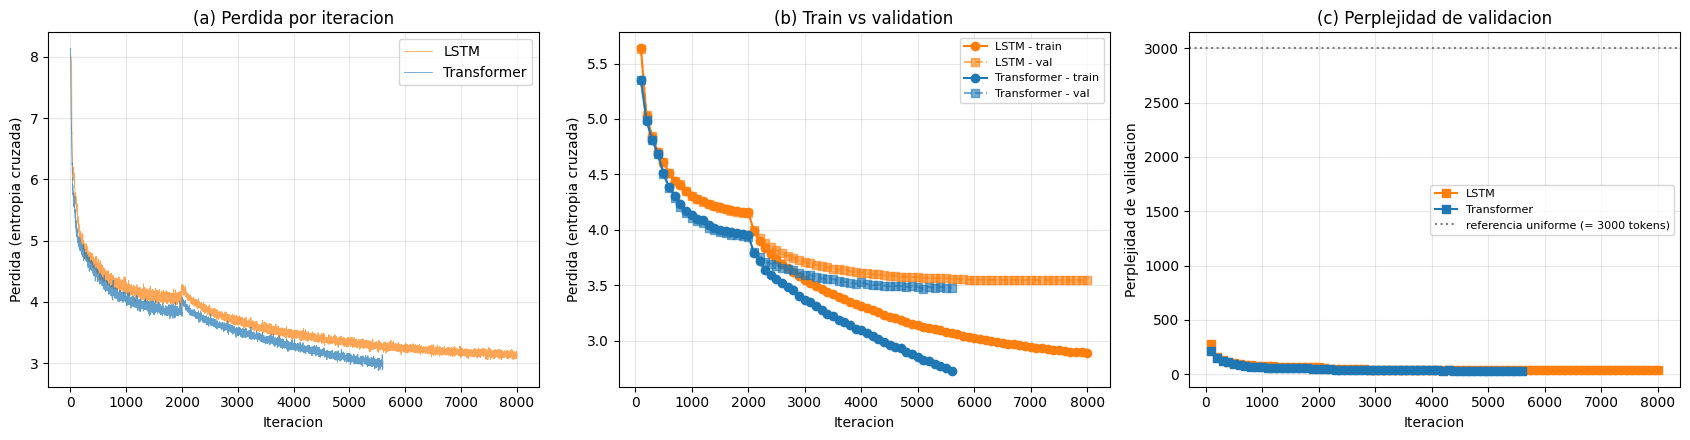

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------------------------------------------
# Curvas de aprendizaje comparadas
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(hist_lstm['loss_training'], linewidth=0.6, color="tab:orange", alpha=0.7, label="LSTM")
axes[0].plot(hist_tr['loss_training'], linewidth=0.6, color="tab:blue", alpha=0.7, label="Transformer")
axes[0].set_xlabel("Iteracion")
axes[0].set_ylabel("Perdida (entropia cruzada)")
axes[0].set_title("(a) Perdida por iteracion")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for h, nombre, color in [(hist_lstm, "LSTM", "tab:orange"), (hist_tr, "Transformer", "tab:blue")]:
    axes[1].plot(h['iters_eval'], h['loss_train_split'], "o-", color=color,
                 label=nombre + " - train")
    axes[1].plot(h['iters_eval'], h['loss_validation_split'], "s--", color=color,
                 alpha=0.6, label=nombre + " - val")
axes[1].set_xlabel("Iteracion")
axes[1].set_ylabel("Perdida (entropia cruzada)")
axes[1].set_title("(b) Train vs validation")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

for h, nombre, color in [(hist_lstm, "LSTM", "tab:orange"), (hist_tr, "Transformer", "tab:blue")]:
    axes[2].plot(h['iters_eval'], [math.exp(l) for l in h['loss_validation_split']],
                 "s-", color=color, label=nombre)
axes[2].axhline(ntokens, color="gray", linestyle=":",
                label="referencia uniforme (= {} tokens)".format(ntokens))
axes[2].set_xlabel("Iteracion")
axes[2].set_ylabel("Perplejidad de validacion")
axes[2].set_title("(c) Perplejidad de validacion")
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
import math

# ---------------------------------------------------------------
# Resultados finales sobre el split de TEST
# ---------------------------------------------------------------

resultados = {}

modelos_evaluacion = [
    ("LSTM", modelo_lstm, hist_lstm),
    ("Transformer", modelo_tr, hist_tr),
]

for nombre, model, hist in modelos_evaluacion:

    loss_test = test(
        model,
        'test',
        EVAL_ITERS,
        verbose=False
    )

    if not math.isfinite(loss_test):
        raise FloatingPointError(
            "La pérdida de test de {} no es finita.".format(nombre)
        )

    resultados[nombre] = {
        "params": sum(p.numel() for p in model.parameters()),
        "minutos": hist["minutos_total"],
        "val_ppl": math.exp(hist["best_val_loss"]),
        "test_loss": loss_test,
        "test_ppl": math.exp(loss_test),
        "bpt": loss_test / math.log(2),
    }


print("=" * 78)
print("RESULTADOS SOBRE EL SPLIT DE TEST")
print("=" * 78)

print(
    "{:<15}{:>14}{:>10}{:>12}{:>12}{:>13}".format(
        "Modelo",
        "Params",
        "Minutos",
        "Val PPL",
        "Test PPL",
        "bits/token"
    )
)

print("-" * 78)

for nombre in ["LSTM", "Transformer"]:
    r = resultados[nombre]

    print(
        "{:<15}{:>14,}{:>10.1f}{:>12.2f}{:>12.2f}{:>13.3f}".format(
            nombre,
            r["params"],
            r["minutos"],
            r["val_ppl"],
            r["test_ppl"],
            r["bpt"]
        )
    )

print("=" * 78)

print("")
print(
    "Referencia uniforme: perplejidad {} ({:.3f} bits/token).".format(
        ntokens,
        math.log2(ntokens)
    )
)

print("")
print(
    "La evaluación de test utiliza {} lotes fijos y reproducibles; "
    "es una estimación por muestreo, no un recorrido exhaustivo del split.".format(
        EVAL_ITERS
    )
)

RESULTADOS SOBRE EL SPLIT DE TEST
Modelo                 Params   Minutos     Val PPL    Test PPL   bits/token
------------------------------------------------------------------------------
LSTM                5,985,208       6.1       34.61       33.62        5.071
Transformer        13,045,944      10.8       32.17       31.50        4.978

Referencia uniforme: perplejidad 3000 (11.551 bits/token).

La evaluación de test utiliza 20 lotes fijos y reproducibles; es una estimación por muestreo, no un recorrido exhaustivo del split.


In [24]:
# ---------------------------------------------------------------
# Diagnostico automatico: convergencia y sobreajuste
# ---------------------------------------------------------------
def diagnosticar(hist, nombre):
    val = hist['loss_validation_split']
    tr = hist['loss_train_split']
    iters = hist['iters_eval']
    i_mejor = min(range(len(val)), key=lambda k: val[k])
    ppl_mejor = math.exp(val[i_mejor])

    print("=" * 74)
    print(f"DIAGNÓSTICO: {nombre}")
    print("=" * 74)
    print(f"  Mejor perplejidad de validación: {ppl_mejor:.2f} (iteración {iters[i_mejor]})")

    if i_mejor < len(val) - 2:
        print("  Estado: Posible sobreajuste detectado (se usa el mejor checkpoint).")
    else:
        print("  Estado: Curva aparentemente estabilizada o en mejora.")
    print(" ")

# Ejecución de diagnósticos
if 'hist_lstm' in locals() and hist_lstm:
    diagnosticar(hist_lstm, "LSTM")
if 'hist_tr' in locals() and hist_tr:
    diagnosticar(hist_tr, "Transformer")

DIAGNÓSTICO: LSTM
  Mejor perplejidad de validación: 34.61 (iteración 7500)
  Estado: Posible sobreajuste detectado (se usa el mejor checkpoint).
 
DIAGNÓSTICO: Transformer
  Mejor perplejidad de validación: 32.17 (iteración 5100)
  Estado: Posible sobreajuste detectado (se usa el mejor checkpoint).
 


## Paso 14.5: ¿Coinciden el óptimo de perplejidad y el de forma?

Ésta es la pregunta que decide si el criterio de parada es el correcto.

El entrenamiento guarda los pesos de la iteración con **mejor perplejidad de validación**, y la parada temprana se dispara cuando esa perplejidad deja de mejorar. Pero la perplejidad mide predicción de tokens, y lo que evaluamos es la forma del soneto. Si ambas cosas alcanzaran su mejor momento en iteraciones distintas, el modelo que se entrega no sería el mejor para la tarea.

Durante el afinado se generaron 16 poemas cada 1000 iteraciones y se midió qué porcentaje tenía la estructura 4-4-3-3. La celda siguiente compara las dos curvas.

Lo que hay que mirar es **si el máximo de forma cae cerca del mínimo de perplejidad o lejos de él**. Si cae cerca, el criterio actual es adecuado y no hay nada que cambiar. Si la forma sigue mejorando después de que la perplejidad haya tocado fondo, entonces parar por perplejidad es parar antes de tiempo, y el modelo entregado está peor de lo que podría.

La muestra de 16 poemas es pequeña y la medida tiene bastante ruido, así que sirve para detectar una tendencia clara, no para afinar una iteración concreta.

In [25]:
# ---------------------------------------------------------------
# Comparacion: donde toca fondo la perplejidad
# y donde alcanza su mejor valor la forma
# ---------------------------------------------------------------

def comparar_optimos(hist, nombre):

    # Debe existir al menos una medicion de forma
    if not hist.get('forma'):
        print("{}: no hay mediciones de forma.".format(nombre))
        return

    val = hist['loss_validation_split']
    iters = hist['iters_eval']

    forma = hist['forma']
    iters_f = hist['iters_forma']

    # descartar posibles NaN
    validas = [
        (it, f)
        for it, f in zip(iters_f, forma)
        if f == f
    ]

    if not validas:
        print("{}: las mediciones de forma no son utilizables.".format(nombre))
        return

    # -----------------------------------------------------------
    # Mejor punto de perplejidad
    # -----------------------------------------------------------
    i_ppl = min(
        range(len(val)),
        key=lambda k: val[k]
    )

    it_ppl = iters[i_ppl]
    mejor_ppl = math.exp(val[i_ppl])

    # -----------------------------------------------------------
    # Valores de forma
    # -----------------------------------------------------------
    valores_forma = [f for _, f in validas]
    max_forma = max(valores_forma)

    print("=" * 74)
    print(nombre)
    print("=" * 74)

    print(
        "  Perplejidad de validacion: minimo en la iteracion {} ({:.2f})".format(
            it_ppl,
            mejor_ppl
        )
    )

    # -----------------------------------------------------------
    # CASO 1:
    # No hubo ningun acierto estructural
    # -----------------------------------------------------------
    if max_forma <= 0.0:

        print(
            "  Estructura 4-4-3-3:        ningun acierto (0.0 %)"
        )

        print("")
        print(
            "  {:>8}  {:>12}  {:>12}".format(
                "iter",
                "val ppl",
                "estructura"
            )
        )
        print("  " + "-" * 36)

        for it_f, f in validas:

            cercano = min(
                range(len(iters)),
                key=lambda k: abs(iters[k] - it_f)
            )

            marcas = ""

            if it_f == it_ppl:
                marcas += "  <- mejor ppl"

            print(
                "  {:>8}  {:>12.2f}  {:>11.1f} %{}".format(
                    it_f,
                    math.exp(val[cercano]),
                    f,
                    marcas
                )
            )

        print("")
        print(
            "  No se observaron aciertos de estructura en las muestras evaluadas."
        )
        print(
            "  No hay señal suficiente para valorar la relacion entre"
        )
        print(
            "  perplejidad y forma ni la adecuacion del criterio de parada."
        )
        print("")

        return

    # -----------------------------------------------------------
    # CASO 2:
    # Existe al menos un valor positivo de forma
    # -----------------------------------------------------------

    best_form_iters = [
        it
        for it, f in validas
        if f == max_forma
    ]

    # Unico maximo
    if len(best_form_iters) == 1:

        print(
            "  Estructura 4-4-3-3:        maximo en la iteracion {} ({:.1f} %)".format(
                best_form_iters[0],
                max_forma
            )
        )

    # Empate entre varias iteraciones
    else:

        print(
            "  Estructura 4-4-3-3:        maximo de {:.1f} % en iteraciones {}".format(
                max_forma,
                ", ".join(map(str, best_form_iters))
            )
        )

    # -----------------------------------------------------------
    # Tabla comparativa
    # -----------------------------------------------------------

    print("")
    print(
        "  {:>8}  {:>12}  {:>12}".format(
            "iter",
            "val ppl",
            "estructura"
        )
    )
    print("  " + "-" * 36)

    for it_f, f in validas:

        cercano = min(
            range(len(iters)),
            key=lambda k: abs(iters[k] - it_f)
        )

        marcas = ""

        if it_f == it_ppl:
            marcas += "  <- mejor ppl"

        if f == max_forma:
            marcas += "  <- mejor forma"

        print(
            "  {:>8}  {:>12.2f}  {:>11.1f} %{}".format(
                it_f,
                math.exp(val[cercano]),
                f,
                marcas
            )
        )

    print("")

    # -----------------------------------------------------------
    # Interpretacion
    # -----------------------------------------------------------

    if len(best_form_iters) > 1:

        print(
            "  LECTURA: varias iteraciones alcanzaron el mismo porcentaje"
        )
        print(
            "  maximo de estructura. No existe un maximo unico observado."
        )

    else:

        it_forma = best_form_iters[0]

        separacion = abs(
            it_forma - it_ppl
        )

        print(
            "  LECTURA: el minimo de perplejidad y el maximo observado"
        )
        print(
            "  de forma estan separados {} iteraciones.".format(
                separacion
            )
        )

        if separacion <= INTERVALO_FORMA:

            print(
                "  La distancia es menor o igual al intervalo de medicion ({})".format(
                    INTERVALO_FORMA
                )
            )

        else:

            print(
                "  La distancia es mayor que el intervalo de medicion ({})".format(
                    INTERVALO_FORMA
                )
            )

    print("")
    print(
        "  Esta comparacion es exploratoria: se utilizan muestras de 16 poemas."
    )
    print(
        "  La coincidencia temporal no demuestra que ambos criterios"
    )
    print(
        "  seleccionen el mejor modelo."
    )
    print("")


# ---------------------------------------------------------------
# Aplicar exactamente el mismo diagnostico a ambos modelos
# ---------------------------------------------------------------

comparar_optimos(
    hist_lstm,
    "LSTM"
)

comparar_optimos(
    hist_tr,
    "TRANSFORMER"
)

LSTM
  Perplejidad de validacion: minimo en la iteracion 7500 (34.61)
  Estructura 4-4-3-3:        maximo en la iteracion 7000 (25.0 %)

      iter       val ppl    estructura
  ------------------------------------
      3000         40.97          0.0 %
      4000         37.04          6.2 %
      5000         35.63          0.0 %
      6000         34.86         12.5 %
      7000         34.79         25.0 %  <- mejor forma
      8000         34.71         18.8 %

  LECTURA: el minimo de perplejidad y el maximo observado
  de forma estan separados 500 iteraciones.
  La distancia es menor o igual al intervalo de medicion (1000)

  Esta comparacion es exploratoria: se utilizan muestras de 16 poemas.
  La coincidencia temporal no demuestra que ambos criterios
  seleccionen el mejor modelo.

TRANSFORMER
  Perplejidad de validacion: minimo en la iteracion 5100 (32.17)
  Estructura 4-4-3-3:        maximo en la iteracion 4000 (56.2 %)

      iter       val ppl    estructura
  -------------

## Paso 15: Sonetos generados por el Transformer

Los mismos ajustes de generación que con la LSTM —misma temperatura, misma semilla, mismo número de poemas— para que la comparación sea directa.

In [42]:
# semilla del generador de numeros aleatorios
# para conseguir resultados deterministas
torch.manual_seed(SEED)

poemas_tr = generar_sonetos(modelo_tr, n_sonetos=128, max_tokens=280,
                            temperature=TEMPERATURA, top_k=TOP_K, seed=SEED)

print("Generados {} poemas. Cerraron correctamente con <fin>: {}".format(
    len(poemas_tr), sum(1 for p in poemas_tr if p["completo"])))
print("")
print("=" * 60)
print("MUESTRA DE SONETOS GENERADOS POR EL TRANSFORMER  (T = {}, top-k = {})".format(
    TEMPERATURA, TOP_K))
print("=" * 60)
mostrar_sonetos(poemas_tr, n=4)

Generados 128 poemas. Cerraron correctamente con <fin>: 127

MUESTRA DE SONETOS GENERADOS POR EL TRANSFORMER  (T = 0.7, top-k = None)
------------------------------------------------------------------
SONETO 1
------------------------------------------------------------------
En inspiración a su poder impresaciente,
al elevar con sus alas,
y al levescente y acata
torna el porvenir el mar y en la vena

Guarda y enciende, y el ardor soberano
en armas arma, y el que, en el moribundo;
del rompe, y se levanta el mundo
oscurece la voz del valiente iracundo:

Cristo guarda, la nación, Minerva,
y con tu nombre en el mundo,
y digno, mi ser, y el mundo.

------------------------------------------------------------------
SONETO 2
------------------------------------------------------------------
Que es la muerte que en la peregrina
con nueva muerte, y con gloria,
porque el templo en culto a tu memoria,
mansión temible, y en en su historia.

Fuiste en el fecundo el coro,
que imita en la memoria
in

In [ ]:
# ---------------------------------------------------------------
# El mismo poema, en las dos formas
# ---------------------------------------------------------------
# El modelo escribe cada verso al reves, empezando por la palabra que rima.
# 'deserializar' deshace la inversion verso a verso, de modo que el poema
# final se lee con normalidad y la rima vuelve a quedar al final de cada
# linea. Todo lo que se muestra y se mide en el cuaderno usa ya esa version.
print("=" * 66)
print("DE LA FORMA INVERTIDA A LA FORMA LEGIBLE")
print("=" * 66)
mostrar_sonetos(poemas_tr, n=1, mostrar_crudo=True)

In [ ]:
# efecto de la temperatura sobre los poemas del Transformer
for T in [0.5, 0.7, 1.0]:
    print("=" * 66)
    print("TEMPERATURA = {}   (top-k = {})".format(T, TOP_K))
    print("=" * 66)
    muestra = generar_sonetos(modelo_tr, n_sonetos=4, max_tokens=280,
                              temperature=T, top_k=TOP_K, seed=SEED)
    print(muestra[0]["texto"])
    print("")

## Paso 16: Análisis métrico automático de los poemas generados

> Qué aporta: es la evaluación de verdad, y aquí se cierra el argumento. La introducción planteaba que contar versos es fácil y rimar es difícil, y que ahí deberían separarse las dos arquitecturas. Esta tabla lo contesta con números.

Se analizan los poemas de cada modelo con las herramientas del Paso 4 y se comparan con los sonetos reales medidos con esas mismas herramientas. Cuatro medidas: si cierra el poema y con qué estructura, cuántos versos salen endecasílabos, si riman los cuartetos en ABBA, y qué esquema completo aparece.

### Sobre qué se calcula cada porcentaje

Las sílabas y la rima se miden sobre todos los poemas que tengan 14 versos, aunque no acierten el reparto en estrofas: para saber si dos versos riman da igual dónde estén las líneas en blanco, y exigir la estructura perfecta dejaría fuera poemas medibles.

Cuando no queda ningún poema que medir, la tabla imprime un guion y no un cero. Son cosas distintas: un cero significa que el modelo lo intentó y falló; un guion, que no llegó a presentarse a la prueba.

### Sobre cuántos poemas se mide

Las cifras de esta tabla se calculan sobre **128 poemas por modelo**. No es un número caprichoso: con 32, que es lo que se usaba en una versión anterior del análisis, el error estándar de la tasa de estructura ronda los 9 puntos porcentuales, y las filas de rima acaban calculándose sobre una docena de poemas.

Conviene además fijarse en el denominador de cada fila. Las de estructura se calculan sobre los 128 poemas generados; las de sílabas y rima, solo sobre los que tienen 14 versos. Cuando un modelo produce pocos poemas bien formados, sus porcentajes de sílabas y rima se apoyan en muy pocos casos y pueden resultar engañosamente altos.

In [ ]:
# ---------------------------------------------------------------
# Analisis de los poemas generados por cada modelo
# ---------------------------------------------------------------
def porcentaje(numerador, denominador):
    # devuelve None cuando no hay nada que medir, para no confundir
    # un "0 %" real con un "no habia muestras que medir"
    if denominador == 0:
        return None
    return 100.0 * numerador / denominador


def analizar_coleccion(poemas):
    n = len(poemas)
    completos = 0
    catorce = 0
    estructura = 0
    silabas = collections.Counter()
    esquemas = collections.Counter()
    abba = 0
    abba_abba = 0

    for p in poemas:
        if p["completo"]:
            completos += 1
        a = analizar_poema(p["texto"])

        # las silabas y la rima se miden sobre TODOS los poemas de 14 versos,
        # tengan o no bien colocadas las lineas en blanco: para saber si dos
        # versos riman da igual como esten agrupadas las estrofas
        if a["n_versos"] == 14:
            catorce += 1
            for s in a["silabas"]:
                silabas[s] += 1
            esquemas[a["esquema"]] += 1
            if a["esquema"][:4] == "ABBA":
                abba += 1
            if a["esquema"][:8] == "ABBAABBA":
                abba_abba += 1

        if a["es_soneto"]:
            estructura += 1

    total_versos = sum(silabas.values())
    return {
        "n": n,
        "n_catorce": catorce,
        "pct_completos": porcentaje(completos, n),
        "pct_catorce": porcentaje(catorce, n),
        "pct_estructura": porcentaje(estructura, n),
        "pct_endeca": porcentaje(silabas[11], total_versos),
        "pct_endeca_margen": porcentaje(silabas[10] + silabas[11] + silabas[12], total_versos),
        "pct_abba": porcentaje(abba, catorce),
        "pct_abba_abba": porcentaje(abba_abba, catorce),
        "esquemas": esquemas,
    }


def celda(valor, ancho):
    # un guion cuando no hubo muestras que medir
    if valor is None:
        return "{:>{}}".format("-", ancho)
    return "{:>{}.1f} %".format(valor, ancho - 2)


an_lstm = analizar_coleccion(poemas_lstm)
an_tr = analizar_coleccion(poemas_tr)

print("=" * 80)
print("ANALISIS METRICO  ({} poemas generados por cada modelo)".format(an_lstm["n"]))
print("=" * 80)
print("{:<40}{:>11}{:>13}{:>15}".format("", "LSTM", "Transformer", "Sonetos reales"))
print("-" * 80)

filas = [
    ("Cierran el poema con el marcador <fin>", "pct_completos", None),
    ("Tienen exactamente 14 versos", "pct_catorce", 100.0),
    ("Tienen estructura 4-4-3-3", "pct_estructura", 100.0),
    ("Versos de 11 silabas exactas", "pct_endeca", REF_ENDECA),
    ("Versos de 11 +- 1 silabas", "pct_endeca_margen", REF_ENDECA_MARGEN),
    ("Primer cuarteto con rima ABBA", "pct_abba", REF_ABBA1),
    ("Los dos cuartetos ABBA ABBA", "pct_abba_abba", REF_ABBA),
]

for etiqueta, clave, referencia in filas:
    print("{:<40}{}{}{}".format(etiqueta,
                                celda(an_lstm[clave], 11),
                                celda(an_tr[clave], 13),
                                celda(referencia, 15)))
print("=" * 80)
print("")
print("Poemas de 14 versos disponibles para medir silabas y rima:")
print("   LSTM: {}     Transformer: {}".format(an_lstm["n_catorce"], an_tr["n_catorce"]))
print("")
print("Un guion '-' significa que no habia ningun poema que medir en esa fila,")
print("que no es lo mismo que un 0 %. Y si el numero de poemas de 14 versos es")
print("pequenyo, los porcentajes de silabas y rima son orientativos: con 5 poemas,")
print("cada uno vale 20 puntos porcentuales.")

In [ ]:
# ---------------------------------------------------------------
# Grafico comparativo y esquemas de rima obtenidos
# ---------------------------------------------------------------
etiquetas = ["14 versos", "4-4-3-3", "11 silabas", "cuarteto\nABBA", "ABBA\nABBA"]
claves = ["pct_catorce", "pct_estructura", "pct_endeca", "pct_abba", "pct_abba_abba"]
refs = [100.0, 100.0, REF_ENDECA, REF_ABBA1, REF_ABBA]

# las barras ausentes (None = no habia nada que medir) se dibujan a cero,
# pero se marcan con una 'x' para no confundirlas con un cero real
def altura(v):
    return 0.0 if v is None else v

x = range(len(etiquetas))
ancho = 0.27

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar([i - ancho for i in x], [altura(an_lstm[c]) for c in claves], ancho,
       label="LSTM", color="tab:orange")
ax.bar(list(x), [altura(an_tr[c]) for c in claves], ancho,
       label="Transformer", color="tab:blue")
ax.bar([i + ancho for i in x], refs, ancho,
       label="Sonetos reales", color="tab:gray", alpha=0.65)

for i, c in enumerate(claves):
    if an_lstm[c] is None:
        ax.text(i - ancho, 2, "x", ha="center", color="tab:orange", fontweight="bold")
    if an_tr[c] is None:
        ax.text(i, 2, "x", ha="center", color="tab:blue", fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(etiquetas)
ax.set_ylabel("% de poemas (o de versos)")
ax.set_title("Forma del soneto: lo generado frente al corpus real\n(una 'x' indica que no habia muestras que medir)")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Esquemas de rima mas frecuentes en los poemas generados:")
for nombre, an in [("LSTM", an_lstm), ("Transformer", an_tr)]:
    print("")
    print("  {} ({} poemas de 14 versos):".format(nombre, an["n_catorce"]))
    if an["esquemas"]:
        for e, c in an["esquemas"].most_common(5):
            canonico = "  <-- esquema canonico" if e[:8] == "ABBAABBA" else ""
            print("     {}   x{}{}".format(e, c, canonico))
    else:
        print("     (ningun poema de 14 versos que analizar)")

```markdown
## Paso 16.5: Búsqueda del mejor soneto entre muchos candidatos

Hay una asimetría que no se había aprovechado: evaluar un soneto es barato y automático, generarlo es lo caro. Las herramientas del Paso 4 puntúan un poema en milisegundos y la generación por lotes produce decenas a la vez. Eso permite generar muchos candidatos y quedarse con los que mejor cumplen la forma, sin reentrenar nada.

La puntuación reparte 100 puntos: 40 por reproducir la estructura 4-4-3-3, 30 según la proporción de versos de 11 sílabas y 30 mediante un F1 de las relaciones de rima entre versos. Esta última medida premia las rimas requeridas y penaliza tanto las rimas ausentes como las coincidencias espurias.

Dos advertencias. Esto no mejora el modelo, solo la selección de sus salidas: la distribución completa describe al modelo, el mejor candidato describe al conjunto modelo más búsqueda. Y al comparar arquitecturas hay que citar la media, no el máximo.
```

In [ ]:
def puntuar_soneto(texto, esquema_objetivo=None):

    if esquema_objetivo is None:
        esquema_objetivo = ESQUEMA_OBJETIVO

    a = analizar_poema(texto)

    detalle = {
        "estructura": 0.0,
        "silabas": 0.0,
        "rima": 0.0,
    }

    # -----------------------------------------------------------
    # 40 puntos: estructura completa 4-4-3-3
    # -----------------------------------------------------------
    if a["es_soneto"]:
        detalle["estructura"] = 40.0

    # -----------------------------------------------------------
    # 30 puntos: proporcion REAL de versos endecasilabos
    # -----------------------------------------------------------
    if a["silabas"]:
        n_endeca = sum(
            1
            for s in a["silabas"]
            if s == 11
        )

        proporcion_endeca = n_endeca / len(a["silabas"])

        detalle["silabas"] = 30.0 * proporcion_endeca

    # -----------------------------------------------------------
    # 30 puntos: relaciones de rima mediante F1
    # -----------------------------------------------------------
    # Solo se puede comparar un esquema completo de 14 posiciones.
    if len(a["esquema"]) == len(esquema_objetivo):

        tp = 0
        fp = 0
        fn = 0

        n = len(esquema_objetivo)

        for i in range(n):
            for j in range(i + 1, n):

                objetivo_mismo = (
                    esquema_objetivo[i] == esquema_objetivo[j]
                )

                generado_mismo = (
                    a["esquema"][i] == a["esquema"][j]
                )

                if objetivo_mismo and generado_mismo:
                    tp += 1

                elif (not objetivo_mismo) and generado_mismo:
                    fp += 1

                elif objetivo_mismo and (not generado_mismo):
                    fn += 1

        denominador = (2 * tp) + fp + fn

        if denominador > 0:
            f1_rima = (2.0 * tp) / denominador
        else:
            f1_rima = 0.0

        detalle["rima"] = 30.0 * f1_rima

    detalle["total"] = (
        detalle["estructura"]
        + detalle["silabas"]
        + detalle["rima"]
    )

    detalle["esquema"] = a["esquema"]

    return detalle

# ---------------------------------------------------------------
# Generamos muchos candidatos y nos quedamos con los mejores
# ---------------------------------------------------------------
N_CANDIDATOS = 16 if MODO_RAPIDO else 256

torch.manual_seed(SEED)
candidatos = generar_sonetos(modelo_tr, n_sonetos=N_CANDIDATOS, max_tokens=320,
                             temperature=TEMPERATURA, top_k=TOP_K, seed=SEED)

for p in candidatos:
    p["puntos"] = puntuar_soneto(p["texto"])

ordenados = sorted(candidatos, key=lambda p: p["puntos"]["total"], reverse=True)
totales = [p["puntos"]["total"] for p in candidatos]

print("=" * 74)
print("DISTRIBUCION DE PUNTUACIONES  ({} candidatos)".format(N_CANDIDATOS))
print("=" * 74)
print("  media:  {:5.1f} / 100      <- esto describe al MODELO".format(
    sum(totales) / len(totales)))
print("  mediana:{:5.1f}".format(sorted(totales)[len(totales) // 2]))
print("  mejor:  {:5.1f}            <- esto describe a modelo + busqueda".format(max(totales)))
print("  peor:   {:5.1f}".format(min(totales)))
print("")

# histograma sencillo por tramos de 20 puntos
print("  Reparto por tramos:")
for lim in range(0, 100, 20):
    n = sum(1 for t in totales if lim <= t < lim + 20)
    print("   {:>3}-{:<3} {} ({})".format(lim, lim + 19, "#" * n, n))
print("")
print("=" * 74)
print("LOS DOS MEJORES CANDIDATOS")
print("=" * 74)
for p in ordenados[:2]:
    d = p["puntos"]
    print("-" * 74)
    print("Puntuacion {:.1f}/100   (estructura {:.0f} + silabas {:.1f} + rima {:.1f})".format(
        d["total"], d["estructura"], d["silabas"], d["rima"]))
    print("Esquema de rima obtenido: {}   objetivo: {}".format(
        d["esquema"] or "(no son 14 versos)", ESQUEMA_OBJETIVO))
    print("-" * 74)
    print(p["texto"])
    print("")

## Paso 16.6: Ajuste de los parámetros de muestreo

La temperatura y el top-k no cambian el modelo: cambian cómo se sortea cada token a partir de las probabilidades que él produce. Eso los convierte en el único parámetro optimizable **sin volver a entrenar**, y en el más barato de ajustar.

Que importan se deduce del propio mecanismo: un soneto son unos 200 tokens, y basta que en uno se cuele un salto de línea improbable para arruinar el recuento de versos. Esa probabilidad se acumula a lo largo de toda la secuencia.

### El experimento

Se compararon 12 combinaciones —cuatro temperaturas por tres valores de top-k— generando **128 poemas con cada una** y puntuándolos con las herramientas del Paso 4.

El número de poemas no es arbitrario. Con 32 por combinación, el error estándar de la tasa de estructura sería de casi 9 puntos porcentuales y solo se distinguirían diferencias mayores de 25 puntos; como las diferencias reales rondan los 5 o 10, se elegiría la ganadora por azar. Con 128 el error baja a 4,1 puntos.

### Qué salió

| Efecto | Resultado |
|---|---|
| Temperatura (promediando los tres top-k) | 0,5 → 38,0 % · 0,7 → 34,1 % · 0,9 → 30,0 % · 1,1 → 28,1 % |
| Top-k (promediando las cuatro temperaturas) | 20 → 29,5 % · 40 → 32,0 % · sin truncar → **36,1 %** |

Dos lecturas. La temperatura tiene un efecto **monótono y claro**: cuanto más conservador el muestreo, mejor sale la forma. Y el top-k va en dirección contraria a la intuición: **truncar la distribución empeora el resultado**, y truncarla mucho (k = 20) lo empeora bastante.

Tiene sentido si se piensa en qué hace el top-k. Recorta la cola para evitar que se cuele un token absurdo, pero también impide al modelo elegir opciones legítimas poco frecuentes. Con un vocabulario de subpalabras y un modelo entrenado, esa cola ya está razonablemente limpia, así que el recorte cuesta más de lo que ahorra.

Las tres mejores combinaciones —`0,7` sin truncar, y `0,5` con k = 20 o 40— quedaron **empatadas estadísticamente** entre sí (z = 0,26), pero las tres superan de forma significativa a la combinación intermedia `0,7 / 40` (z = 2,4 y 2,1).

### Qué se eligió, y por qué

`TEMPERATURA = 0.7` y `TOP_K = None`, fijados en el Paso 8.

Entre las tres empatadas se eligió ésta porque la puntuación mide la forma pero **no mide la variedad**. Una temperatura de 0,5 con truncamiento es doblemente conservadora y tiende a producir poemas parecidos entre sí, un defecto que la tabla no penaliza pero que sí importa en un generador de poesía.

El barrido queda desactivado en el cuaderno: tarda doce minutos y su resultado son estos dos números, así que reejecutarlo en cada corrida no aportaría nada.

In [43]:
# ---------------------------------------------------------------
# Barrido de temperatura y top-k (desactivado por defecto)
# ---------------------------------------------------------------
# Poner en True para ejecutarlo. Tarda unos 12 minutos y no reentrena
# nada: usa el modelo ya entrenado. Sus resultados son los dos valores
# TEMPERATURA y TOP_K que se fijan en el Paso 8.
EJECUTAR_BARRIDO = False

N_POR_COMBINACION = 32 if MODO_RAPIDO else 128
TEMPERATURAS = [0.5, 0.7, 0.9, 1.1]
TOP_KS = [20, 40, None]

if EJECUTAR_BARRIDO:
    resultados_barrido = []
    t0 = time.time()

    for T in TEMPERATURAS:
        for k in TOP_KS:
            muestra = generar_sonetos(modelo_tr, n_sonetos=N_POR_COMBINACION,
                                      max_tokens=320, temperature=T, top_k=k,
                                      seed=SEED)
            puntos = [puntuar_soneto(p["texto"])["total"] for p in muestra]
            estructura = [1.0 for p in muestra
                          if analizar_poema(p["texto"])["es_soneto"]]

            resultados_barrido.append({
                "T": T,
                "k": k,
                "media": sum(puntos) / len(puntos),
                "mejor": max(puntos),
                "pct_soneto": 100.0 * len(estructura) / len(muestra),
            })
            print("  T={:.1f}  top_k={:<4}  media {:5.1f}  estructura {:5.1f} %  ({:.0f}s)".format(
                T, str(k), resultados_barrido[-1]["media"],
                resultados_barrido[-1]["pct_soneto"], time.time() - t0))

    # error estandar de la tasa de estructura, para saber que diferencias
    # son reales y cuales son ruido del muestreo
    p_media = sum(r["pct_soneto"] for r in resultados_barrido) / len(resultados_barrido) / 100.0
    ee = 100.0 * math.sqrt(max(p_media * (1 - p_media), 1e-9) / N_POR_COMBINACION)

    print("")
    print("=" * 72)
    print("BARRIDO DE MUESTREO  ({} poemas por combinacion)".format(N_POR_COMBINACION))
    print("=" * 72)
    print("{:>6}{:>8}{:>12}{:>14}{:>10}".format("T", "top_k", "Media/100", "Estructura", "Mejor"))
    print("-" * 72)
    for r in sorted(resultados_barrido, key=lambda x: x["media"], reverse=True):
        print("{:>6.1f}{:>8}{:>12.1f}{:>13.1f} %{:>10.1f}".format(
            r["T"], str(r["k"]), r["media"], r["pct_soneto"], r["mejor"]))
    print("=" * 72)

    ganador = max(resultados_barrido, key=lambda x: x["media"])
    print("")
    print("Mejor combinacion por puntuacion media: T = {}, top_k = {}".format(
        ganador["T"], ganador["k"]))
    print("")
    print("AVISO: el error estandar de la tasa de estructura es de {:.1f} puntos,".format(ee))
    print("asi que dos combinaciones que difieran en menos de {:.0f} puntos NO son".format(2.8 * ee))
    print("distinguibles con esta muestra. Si el ganador esta dentro de ese margen")
    print("respecto a otros, cualquiera de ellos sirve: elegid el de temperatura")
    print("mas baja, que produce texto mas conservador.")

else:
    print("EJECUTAR_BARRIDO = False.")
    print("")
    print("El cuaderno genera con los valores fijados en el Paso 8:")
    print("   TEMPERATURA = {}   TOP_K = {}".format(TEMPERATURA, TOP_K))
    print("")
    print("Para reajustarlos, poner EJECUTAR_BARRIDO = True y ejecutar esta celda.")
    print("Tarda unos 12 minutos y no reentrena nada.")

EJECUTAR_BARRIDO = False.

El cuaderno genera con los valores fijados en el Paso 8:
   TEMPERATURA = 0.7   TOP_K = None

Para reajustarlos, poner EJECUTAR_BARRIDO = True y ejecutar esta celda.
Tarda unos 12 minutos y no reentrena nada.


## Paso 17: Verificación de que los modelos no copian el corpus

Un modelo que memorizara el corpus sacaría notas perfectas en todo el Paso 16: estructura impecable, endecasílabos y rima ABBA. Por eso el análisis métrico, por sí solo, no basta para dar el trabajo por bueno.

Se miden dos cosas. Primero, qué porcentaje de las palabras generadas presentes en DISCO-train. Segundo, el solapamiento literal: se toman ventanas del texto generado y se busca si aparecen tal cual en DISCO-train. Compartir fragmentos cortos es inevitable en cualquier texto en español; lo que delataría memorización son coincidencias del tamaño de un verso entero o más.

Sobre el primer número conviene un matiz: con subpalabras, parte del mérito es de la representación. Pero no está garantizado, y si la cifra difiere mucho entre los dos modelos esa diferencia sí es del entrenamiento.

In [ ]:
# ---------------------------------------------------------------
# 1. Palabras que existen   2. Solapamiento literal
# ---------------------------------------------------------------
# IMPORTANTE: la comparacion se hace contra el corpus en ORDEN NATURAL
# de lectura, el mismo en el que estan los poemas generados una vez
# deshecha la inversion. Compararlo contra el texto invertido que ve el
# modelo daria siempre 0 % de solapamiento y la comprobacion no valdria
# para nada.
texto_train_ref = "\n".join(corpus.sonetos_train)

patron_palabra = re.compile(r"[a-záéíóúüñA-ZÁÉÍÓÚÜÑ]+")
vocabulario_real = set(p.lower() for p in patron_palabra.findall(texto_train_ref))

VENTANA = 40   # longitud de las ventanas que buscamos literalmente
PASO = 10      # cada cuantos caracteres tomamos una ventana


def comprobar_copia(poemas, nombre):
    texto = "\n".join(p["texto"] for p in poemas)

    palabras = [p.lower() for p in patron_palabra.findall(texto)]
    existen = [p for p in palabras if p in vocabulario_real]
    inventadas = [p for p in palabras if p not in vocabulario_real]
    pct_existen = 100.0 * len(existen) / max(len(palabras), 1)

    ventanas = copiadas = 0
    copia_mas_larga = ""
    for i in range(0, max(len(texto) - VENTANA, 0), PASO):
        v = texto[i:i + VENTANA]
        ventanas += 1
        if v in texto_train_ref:
            copiadas += 1
            # limitamos la extension: si ya copio 300 caracteres seguidos,
            # el diagnostico esta claro y no hace falta seguir
            fin = i + VENTANA
            tope = min(len(texto), i + 300)
            while fin < tope and texto[i:fin + 1] in texto_train_ref:
                fin += 1
            if (fin - i) > len(copia_mas_larga):
                copia_mas_larga = texto[i:fin]

    pct_copiado = 100.0 * copiadas / max(ventanas, 1)

    print("-" * 70)
    print(nombre)
    print("-" * 70)
    print("  Palabras generadas:                  {}".format(len(palabras)))
    print("  Palabras presentes en DISCO-train:   {:.1f} %".format(pct_existen))
    print("  Ventanas de {} caracteres copiadas:  {:.1f} % ({} de {})".format(
        VENTANA, pct_copiado, copiadas, ventanas))
    print("  Fragmento copiado mas largo:         {} caracteres".format(len(copia_mas_larga)))
    if copia_mas_larga:
        print("     " + repr(copia_mas_larga[:120]))
    print("  Ejemplos de palabras inventadas:")
    print("     " + str(inventadas[:12] if inventadas else "(ninguna)"))
    return pct_existen, pct_copiado


print("=" * 70)
print("COMPROBACION DE MEMORIZACION")
print("=" * 70)
ex_lstm, cp_lstm = comprobar_copia(poemas_lstm, "LSTM")
print("")
ex_tr, cp_tr = comprobar_copia(poemas_tr, "TRANSFORMER")

print("")
print("=" * 70)
if cp_tr >= 5:
    print("Hay demasiado texto literal del corpus: el modelo esta memorizando.")
    print("Convendria subir el dropout o entrenar menos iteraciones.")
else:
    print("No se detecta copia literal relevante del split de entrenamiento de DISCO mediante la prueba de ventanas utilizada.")
    print("")
    print("Nota sobre el porcentaje de palabras presentes en DISCO-train: con BPE parte del")
    print("merito es de la representacion, porque el modelo compone a partir de")
    print("subpalabras reales. Pero NO esta garantizado: encadenar subpalabras")
    print("validas en un orden que no forma ninguna palabra del espanyol sigue")
    print("siendo posible. Si la cifra difiere mucho entre los dos modelos, esa")
    print("diferencia si es merito (o demerito) del entrenamiento.")
    print("Diferencia observada: LSTM {:.1f} %  frente a Transformer {:.1f} %".format(
        ex_lstm, ex_tr))
    print("La prueba de verdad para estos modelos, en todo caso, es el Paso 16.")
print("=" * 70)

In [ ]:
if MODO_RAPIDO:
    print("=" * 78)
    print("NOTA SOBRE ESTA EJECUCIÓN")
    print("=" * 78)
    print("MODO_RAPIDO=True: esta ejecución valida el funcionamiento de punta a punta.")
    print("Sus métricas no representan el rendimiento final de los modelos.")
    print("Las conclusiones numéricas siguientes corresponden a la ejecución completa")
    print("realizada con MODO_RAPIDO=False.")
    print("=" * 78)

from IPython.display import Markdown, display


def fmt_pct(valor):
    if valor is None:
        return "no disponible"
    return "{:.1f}%".format(valor)


ppl_lstm = resultados["LSTM"]["test_ppl"]
ppl_tr = resultados["Transformer"]["test_ppl"]

params_lstm = resultados["LSTM"]["params"]
params_tr = resultados["Transformer"]["params"]

lectura_memoria = (
    "La prueba de ventanas no detectó copia literal relevante "
    "de DISCO-train en las generaciones del Transformer."
    if cp_tr < 5
    else
    "La prueba de ventanas detectó coincidencias que requieren "
    "una revisión adicional antes de descartar memorización."
)

texto_final = f"""
# Paso 18: Conclusiones

## Resultado principal

Los resultados muestran que los modelos de predicción del siguiente token
pueden aprender parte de la estructura formal del soneto sin recibir reglas
explícitas de métrica o rima.

En las configuraciones evaluadas, el **Transformer obtuvo el mejor
rendimiento global**.

## Perplejidad

- Transformer: **{ppl_tr:.2f}**
- LSTM: **{ppl_lstm:.2f}**

La evaluación de test utiliza lotes fijos y reproducibles del split de test.
Por tanto, representa una estimación reproducible por muestreo y no un
recorrido exhaustivo de todos los tokens del conjunto.

## Forma del soneto

### Transformer

- Cierre correcto con `<fin>`: **{fmt_pct(an_tr["pct_completos"])}**
- Exactamente 14 versos: **{fmt_pct(an_tr["pct_catorce"])}**
- Estructura 4-4-3-3: **{fmt_pct(an_tr["pct_estructura"])}**
- Versos de 11 sílabas exactas: **{fmt_pct(an_tr["pct_endeca"])}**
- Versos dentro del margen 10-12 sílabas:
  **{fmt_pct(an_tr["pct_endeca_margen"])}**
- Primer cuarteto ABBA: **{fmt_pct(an_tr["pct_abba"])}**
- Dos cuartetos ABBA ABBA:
  **{fmt_pct(an_tr["pct_abba_abba"])}**

### LSTM

- Exactamente 14 versos: **{fmt_pct(an_lstm["pct_catorce"])}**
- Estructura 4-4-3-3: **{fmt_pct(an_lstm["pct_estructura"])}**

Como referencia, las mismas herramientas automáticas aplicadas a los
sonetos reales obtienen **{REF_ABBA1:.1f}%** para el primer cuarteto ABBA
y **{REF_ABBA:.1f}%** para ABBA ABBA.

## Interpretación

La diferencia más clara entre las dos configuraciones aparece en la
estructura global.

El Transformer produjo con mucha mayor frecuencia poemas de 14 versos
y el patrón 4-4-3-3.

La métrica endecasílaba y, especialmente, la rima consonante continúan
siendo restricciones considerablemente más difíciles.

Los resultados muestran que una menor pérdida de predicción de tokens
no implica automáticamente el aprendizaje perfecto de todas las
propiedades formales del soneto.

La inversión de palabras dentro de cada verso facilita la decisión de la
palabra que porta la rima, pero no garantiza por sí sola que el esquema
de rima final sea correcto.

## Selección de candidatos

El Paso 16.5 genera múltiples candidatos y los ordena mediante criterios
automáticos de estructura, métrica y relaciones de rima.

Este procedimiento **no modifica los pesos del modelo**.

Por tanto, la distribución completa de poemas describe el comportamiento
del modelo, mientras que el mejor candidato describe el sistema
**modelo + selección posterior**.

## Memorización

{lectura_memoria}

Esta comprobación se limita al split de entrenamiento de DISCO y no
demuestra ausencia absoluta de coincidencias con todos los textos del
corpus de preentrenamiento.

## Limitaciones

El Transformer contiene **{params_tr:,} parámetros** y la LSTM
**{params_lstm:,} parámetros**.

Por tanto, las diferencias observadas corresponden a las configuraciones
estudiadas y no pueden atribuirse exclusivamente a la arquitectura.

Las herramientas automáticas de conteo silábico y detección de rima son
aproximaciones y no sustituyen un análisis métrico profesional.

Las tasas de rima se calculan únicamente sobre los poemas que alcanzan
14 versos y deben interpretarse considerando ese denominador.

La comparación entre el óptimo de perplejidad y el óptimo de forma del
Paso 14.5 es exploratoria porque utiliza muestras pequeñas.

El barrido histórico de temperatura y `top-k` del Paso 16.6 precede a la
corrección final de la función de puntuación. Por ello sus cifras no deben
reinterpretarse como una validación cuantitativa de la métrica actual.

## Conclusión final

En las configuraciones estudiadas, el Transformer ofrece el mejor
compromiso entre capacidad predictiva y aprendizaje de la estructura
global del soneto.

El experimento muestra que **estructura, métrica y rima son objetivos
relacionados pero no equivalentes**, y deben evaluarse por separado.

La estructura 4-4-3-3 resulta sustancialmente más accesible para el modelo
que la métrica endecasílaba y la rima consonante, que permanecen como los
componentes formales más exigentes de la tarea.
"""

display(Markdown(texto_final))


```markdown
# Paso 19: SonetoLab — Puesta en producción

El trabajo no termina en comparar métricas. Como aplicación del modelo seleccionado se construye **SonetoLab**, un prototipo de inferencia que convierte el Transformer entrenado en un generador utilizable.

La aplicación no modifica ni reentrena el modelo. Su aporte consiste en incorporar una capa de control de calidad posterior a la generación:

**Transformer → múltiples candidatos → evaluación formal → ranking → mejor soneto**

Cada candidato se analiza con las mismas herramientas utilizadas durante la evaluación experimental. La puntuación combina estructura, métrica y relaciones de rima.

Por tanto, debe distinguirse entre:

- **calidad del modelo**, que se mide sobre la distribución completa de poemas generados;
- **calidad del producto**, que puede mejorar seleccionando automáticamente la mejor salida entre varios candidatos.

SonetoLab representa una prueba de concepto de puesta en producción, no una nueva arquitectura ni una mejora del entrenamiento.
```

In [ ]:
import json
import shutil
from pathlib import Path

# ---------------------------------------------------------------
# SONETOLAB — artefactos de producción
# ---------------------------------------------------------------

DIRECTORIO_SONETOLAB = Path("sonetolab")
DIRECTORIO_SONETOLAB.mkdir(exist_ok=True)

RUTA_MODELO = DIRECTORIO_SONETOLAB / "transformer_model.pt"
RUTA_TOKENIZADOR = DIRECTORIO_SONETOLAB / "tokenizador_bpe.json"
RUTA_CONFIG = DIRECTORIO_SONETOLAB / "config_modelo.json"


# Guardamos los pesos que estén cargados actualmente en modelo_tr.
# Después de la ejecución completa serán los pesos del mejor checkpoint.
torch.save(
    modelo_tr.state_dict(),
    RUTA_MODELO
)


# Copiamos el tokenizador BPE entrenado.
if not Path(ARCHIVO_TOKENIZADOR).exists():
    raise FileNotFoundError(
        "No se encontró el tokenizador: {}".format(
            ARCHIVO_TOKENIZADOR
        )
    )

shutil.copy2(
    ARCHIVO_TOKENIZADOR,
    RUTA_TOKENIZADOR
)


config_modelo = {
    "arquitectura": "Transformer decoder-only",
    "vocab_size": int(ntokens),
    "block_size": int(block_size),
    "n_embd": int(n_embd),
    "n_head": int(n_head),
    "n_layer": int(n_layer),
    "dropout": float(dropout),
    "invertir_versos": bool(INVERTIR_VERSOS),
    "patron_soneto": list(PATRON_SONETO),
    "temperatura_default": float(TEMPERATURA),
    "top_k_default": TOP_K,
    "esquema_objetivo": ESQUEMA_OBJETIVO,
    "marcadores": {
        "inicio": INICIO,
        "verso": VERSO,
        "estrofa": ESTROFA,
        "fin": FIN,
        "desconocido": DESCONOCIDO,
    },
}


with open(
    RUTA_CONFIG,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        config_modelo,
        f,
        ensure_ascii=False,
        indent=2
    )


print("=" * 68)
print("SONETOLAB — ARTEFACTOS DE PRODUCCIÓN")
print("=" * 68)

print("Modelo:      ", RUTA_MODELO)
print("Tokenizador: ", RUTA_TOKENIZADOR)
print("Configuración:", RUTA_CONFIG)

print("")
print(
    "Parámetros exportados: {:,}".format(
        sum(
            p.numel()
            for p in modelo_tr.parameters()
        )
    )
)

In [ ]:
def sonetolab_generar(
    n_candidatos=32,
    temperatura=0.7,
    top_k=None,
    semilla=42
):
    """
    Genera varios candidatos con el Transformer y devuelve
    automáticamente el de mayor puntuación formal.
    """

    n_candidatos = int(n_candidatos)
    temperatura = float(temperatura)
    semilla = int(semilla)

    if n_candidatos < 1:
        raise ValueError(
            "n_candidatos debe ser mayor que cero."
        )

    if temperatura <= 0:
        raise ValueError(
            "La temperatura debe ser mayor que cero."
        )


    # Interpretación del parámetro top-k de la interfaz.
    if top_k in [
        None,
        "None",
        "Sin truncar",
        "sin truncar",
        ""
    ]:
        k = None

    else:
        k = int(top_k)

        if k <= 0:
            raise ValueError(
                "top_k debe ser positivo o None."
            )


    candidatos = generar_sonetos(
        modelo_tr,
        n_sonetos=n_candidatos,
        max_tokens=320,
        temperature=temperatura,
        top_k=k,
        seed=semilla
    )


    if not candidatos:
        raise RuntimeError(
            "El modelo no devolvió candidatos."
        )


    for candidato in candidatos:

        candidato["puntos"] = puntuar_soneto(
            candidato["texto"]
        )


    candidatos = sorted(
        candidatos,
        key=lambda p: p["puntos"]["total"],
        reverse=True
    )


    mejor = candidatos[0]
    puntos = mejor["puntos"]

    analisis = analizar_poema(
        mejor["texto"]
    )


    n_endeca = sum(
        1
        for s in analisis["silabas"]
        if s == 11
    )


    resumen = {
        "puntuacion_total": puntos["total"],
        "estructura": puntos["estructura"],
        "metrica": puntos["silabas"],
        "rima": puntos["rima"],
        "n_versos": analisis["n_versos"],
        "patron": analisis["patron"],
        "endecasilabos": n_endeca,
        "esquema_rima": puntos["esquema"],
        "candidatos_evaluados": len(candidatos),
        "temperatura": temperatura,
        "top_k": k,
        "semilla": semilla,
    }


    return mejor["texto"], resumen, candidatos


print(
    "Motor SonetoLab definido correctamente."
)

In [ ]:
def sonetolab_interfaz(
    n_candidatos,
    temperatura,
    top_k,
    semilla
):

    poema, resumen, candidatos = sonetolab_generar(
        n_candidatos=n_candidatos,
        temperatura=temperatura,
        top_k=top_k,
        semilla=semilla
    )


    informe = """
### Evaluación automática

**Puntuación total:** {:.1f} / 100

- Estructura: {:.1f} / 40
- Métrica: {:.1f} / 30
- Rima: {:.1f} / 30

**Versos:** {}

**Estructura detectada:** {}

**Versos de 11 sílabas:** {}

**Esquema de rima:** `{}`

**Candidatos evaluados:** {}

### Parámetros de generación

- Temperatura: {}
- top-k: {}
- Semilla: {}

> El resultado mostrado es el candidato mejor puntuado entre
> todos los generados. La selección posterior no modifica
> los pesos del Transformer.
""".format(
        resumen["puntuacion_total"],
        resumen["estructura"],
        resumen["metrica"],
        resumen["rima"],
        resumen["n_versos"],
        resumen["patron"],
        resumen["endecasilabos"],
        resumen["esquema_rima"] or "no disponible",
        resumen["candidatos_evaluados"],
        resumen["temperatura"],
        resumen["top_k"],
        resumen["semilla"],
    )


    return poema, informe


print(
    "Función de interfaz SonetoLab definida."
)

In [44]:
# ---------------------------------------------------------------
# SONETOLAB — interfaz Gradio
# ---------------------------------------------------------------

try:
    import gradio as gr

except ImportError:
    import subprocess
    import sys

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "gradio"
    ])

    import gradio as gr


with gr.Blocks(
    title="SonetoLab"
) as sonetolab_app:

    gr.Markdown(
        """
# SonetoLab

### Generación y selección automática de sonetos

El Transformer genera múltiples candidatos y el sistema selecciona
automáticamente el de mejor puntuación formal.

La evaluación considera:

- estructura 4-4-3-3;
- proporción de versos de 11 sílabas;
- relaciones de rima.

La selección posterior no modifica ni reentrena el modelo.
"""
    )


    with gr.Row():

        n_candidatos_ui = gr.Slider(
            minimum=8,
            maximum=64,
            value=32,
            step=8,
            label="Número de candidatos"
        )

        temperatura_ui = gr.Slider(
            minimum=0.4,
            maximum=1.1,
            value=0.7,
            step=0.1,
            label="Temperatura"
        )


    with gr.Row():

        top_k_ui = gr.Dropdown(
            choices=[
                "Sin truncar",
                "20",
                "40"
            ],
            value="Sin truncar",
            label="Top-k"
        )

        semilla_ui = gr.Number(
            value=SEED,
            precision=0,
            label="Semilla"
        )


    boton_generar = gr.Button(
        "Generar y seleccionar mejor soneto",
        variant="primary"
    )


    poema_salida = gr.Textbox(
        label="Mejor soneto generado",
        lines=18,
        interactive=False
    )


    informe_salida = gr.Markdown()


    boton_generar.click(
        fn=sonetolab_interfaz,
        inputs=[
            n_candidatos_ui,
            temperatura_ui,
            top_k_ui,
            semilla_ui
        ],
        outputs=[
            poema_salida,
            informe_salida
        ]
    )


print("Interfaz SonetoLab creada correctamente.")
print(
    "La aplicación todavía NO se ha lanzado. "
    "Ejecutar la celda launch solo después de la corrida definitiva."
)

Interfaz SonetoLab creada correctamente.
La aplicación todavía NO se ha lanzado. Ejecutar la celda launch solo después de la corrida definitiva.


In [45]:
# ---------------------------------------------------------------
# Lanzamiento opcional de SonetoLab
# ---------------------------------------------------------------

EJECUTAR_SONETOLAB = False

if EJECUTAR_SONETOLAB:
    sonetolab_app.launch(
        share=True,
        debug=False
    )
else:
    print(
        "SonetoLab preparado. "
        "Cambiar EJECUTAR_SONETOLAB=True para abrir la aplicación."
    )


SonetoLab preparado. Cambiar EJECUTAR_SONETOLAB=True para abrir la aplicación.


In [46]:
poema_produccion, resumen_produccion, _ = sonetolab_generar(
    n_candidatos=32,
    temperatura=0.7,
    top_k=None,
    semilla=42
)

print("=" * 72)
print("SONETOLAB — RESULTADO FINAL DE PRODUCCIÓN")
print("=" * 72)
print(poema_produccion)
print("")
print("Puntuación total:  {:.1f}/100".format(resumen_produccion["puntuacion_total"]))
print("Estructura:        {:.1f}/40".format(resumen_produccion["estructura"]))
print("Métrica:           {:.1f}/30".format(resumen_produccion["metrica"]))
print("Rima:              {:.1f}/30".format(resumen_produccion["rima"]))
print("Versos:            {}".format(resumen_produccion["n_versos"]))
print("Patrón:            {}".format(resumen_produccion["patron"]))
print("Endecasílabos:     {}".format(resumen_produccion["endecasilabos"]))
print("Esquema de rima:   {}".format(resumen_produccion["esquema_rima"]))
print("Candidatos:        {}".format(resumen_produccion["candidatos_evaluados"]))

SONETOLAB — RESULTADO FINAL DE PRODUCCIÓN
Esta es que amarga el alma de Fernix,
de Dios, inmortal, y de la gloria
es la verdad de la victoria,
en la voz del templo del tirano.

Y tú, no presto, te tuviste,
a tu ley infeliz, de tu memoria,
a que te diga en el que en la historia
ni eres el ideal de tu nombre

Si eres Señor, de mi destino
tú la música, pues que me resiste,
recuerdo tu espíritu divino.

y en mi corazón en vano
si tú eres tú como eres el profano,
que te bendigo a que eres humano.

Puntuación total:  63.6/100
Estructura:        40.0/40
Métrica:           8.6/30
Rima:              15.0/30
Versos:            14
Patrón:            (4, 4, 3, 3)
Endecasílabos:     4
Esquema de rima:   ABBCDBBEFDFCCC
Candidatos:        32
